Hi

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Bank Customer Churn Analysis
</div>


## Project Overview

This project aims to analyze customer data and identify factors
associated with customer churn.

## Objective

The objective of this notebook is to understand the structure,
content, and quality of the raw dataset before data cleaning
and exploratory data analysis.

In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)


In [6]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy.stats import skew

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve, auc)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import shapiro, probplot
from scipy.stats import mannwhitneyu
from scipy.stats import levene
from scipy.stats import ttest_ind

from scipy.stats import kruskal
from scipy.stats import anderson
from scipy.stats import normaltest


## 2. Load Dataset

### 2.1 Check Available Sheets

In [88]:
excel_file = pd.ExcelFile(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx"
)

print(excel_file.sheet_names)

['Customer_Info', 'Account_Info']


### 2.2 Load the Customer_Info and Account_Info Sheets

In [89]:
# Read Customer_Info sheet
df_customer = pd.read_excel(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx",
    sheet_name="Customer_Info"
)

# Read Account_Info sheet
df_account = pd.read_excel(
    "C:/Users/Redmi/.vscode/Bank_churn/Bank_Churn_Messy.xlsx",
    sheet_name="Account_Info"
)

print("Customer_Info:")
display(df_customer.head())

print("Account_Info:")
display(df_account.head())

Customer_Info:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


Account_Info:


,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Dataset Overview
</div>

## 3. Dataset Overview

In [90]:
# Check the number of rows and columns on Customer_Info sheet

print("Number of rows:", df_customer.shape[0])
print("Number of columns:", df_customer.shape[1])

# Display column names of customer sheet

print("Column names:")
print(df_customer.columns.tolist())

# Display dataset information

print("Customer_Info sheet information")
df_customer.info()



# Check the number of rows and columns on Account_Info sheet 

print("\nNumber of rows:", df_account.shape[0])
print("Number of columns:", df_account.shape[1])

# Display column names of account sheet

print("Column names:")
print(df_account.columns.tolist())

# Display dataset information

print("Account_Info sheet information")
df_account.info()

Number of rows: 10001
Number of columns: 8
Column names:
['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'EstimatedSalary']
Customer_Info sheet information
<class 'pandas.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10001 non-null  int64  
 1   Surname          9998 non-null   str    
 2   CreditScore      10001 non-null  int64  
 3   Geography        10001 non-null  str    
 4   Gender           10001 non-null  str    
 5   Age              9998 non-null   float64
 6   Tenure           10001 non-null  int64  
 7   EstimatedSalary  10001 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 625.2 KB

Number of rows: 10002
Number of columns: 7
Column names:
['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure', 'IsActiveMember', 'Exited']
Account_Info sheet information
<class 'pan

#### Based on data types:
The Age column is stored as the float64 data type. This may be due to the presence of missing values. The data type and values should be reviewed during the data-cleaning process.

The EstimatedSalary column is stored as a string/object data type, although salary is expected to be a numerical variable. The column should be examined for formatting issues and converted to an appropriate numerical data type during data cleaning.

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Data Quality Check
</div>

## 4. Data Quality Assessment

In [91]:
# Check missing values

missing_values_customer = df_customer.isnull().sum()

print("Missing values of customer sheet:")
print(missing_values_customer)


missing_values_account = df_account.isnull().sum()

print("\nMissing values of account sheet:")
print(missing_values_account)


Missing values of customer sheet:
CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
dtype: int64

Missing values of account sheet:
CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64


The Customer_Info sheet contains missing values in two columns: Surname and Age

The Account_Info sheet does not contain any missing values.

Therefore, further data cleaning is required for the Surname and Age columns. The appropriate treatment for these missing values will be determined after examining the affected records and considering the nature and analytical importance of each variable.



In [92]:
# Check for duplicated rows in both sheets

duplicate_rows_customer = df_customer.duplicated().sum()

print("Number of duplicated rows in customer_info sheet:", duplicate_rows_customer)

duplicate_rows_account = df_account.duplicated().sum()
print("\nNumber of duplicated rows in account_info sheet:", duplicate_rows_account)

# Display all duplicated rows
display(
    df_customer[
        df_customer.duplicated(keep=False)
    ]
)

display(
    df_account[
        df_account.duplicated(keep=False)
    ]
)

Number of duplicated rows in customer_info sheet: 1

Number of duplicated rows in account_info sheet: 2


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
9999,15628319,Walker,792,French,Female,28.0,4,€38190.78
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78


,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
10000,15628319,€130142.79,1,No,4,No,0
10001,15628319,€130142.79,1,No,4,No,0


In [12]:
# Check for duplicated CustomerId values in both sheets

print(
    "Duplicated CustomerId values in Customer_Info:",
    df_customer["CustomerId"].duplicated().sum()
)

print(
    "Duplicated CustomerId values in Account_Info:",
    df_account["CustomerId"].duplicated().sum()
)

Duplicated CustomerId values in Customer_Info: 1
Duplicated CustomerId values in Account_Info: 2


In [93]:
# Check the number of unique values in each column in 2 sheet 

unique_values_customer = df_customer.nunique()

print("Number of unique values in customer_info sheet:")
print(unique_values_customer)

# Check the number of the unique values in each column

unique_values_account = df_account.nunique()
print("\nNumber of unique values in account_info sheet:")
print(unique_values_account)

Number of unique values in customer_info sheet:
CustomerId         10000
Surname             2932
CreditScore          460
Geography              5
Gender                 2
Age                   70
Tenure                11
EstimatedSalary     9997
dtype: int64

Number of unique values in account_info sheet:
CustomerId        10000
Balance            6382
NumOfProducts         4
HasCrCard             2
Tenure               11
IsActiveMember        2
Exited                2
dtype: int64


The Customer_Info sheet contains 1 duplicated row. The sheet has 10,001 rows but only 10,000 unique CustomerId values. This result is consistent with the duplicate check and indicates that one customer record is duplicated.

The Account_Info sheet contains 2 duplicated rows. The sheet has 10,002 rows but only 10,000 unique CustomerId values. This result is consistent with the duplicate check and indicates that two customers record are duplicated.

Most categorical variables have a limited number of unique values. For example, Gender has 2 unique values, while HasCrCard, IsActiveMember, and Exited also have 2 unique values. These result are generally valid for binary variables.

The EstimatedSalary column has 9,997 unique values, indicating that most salary values are distinct. However, this column is currently stored as a string and should be checked for formatting issues before being converted to a numerical data type.

In [94]:
# Examine the values in EstimatedSalary

print(
    df_customer["EstimatedSalary"]
    .head(20)
)

0     €101348.88
1     €112542.58
2     €113931.57
3      €93826.63
4       €79084.1
5     €149756.71
6       €10062.8
7     €119346.88
8       €74940.5
9      €71725.73
10     €80181.12
11     €76390.01
12     €26260.98
13    €190857.79
14     €65951.65
15     €64327.26
16      €5097.67
17     €14406.41
18    €158684.81
19     €54724.03
Name: EstimatedSalary, dtype: str


The `EstimatedSalary` column is stored as a string data type because each value contains the euro currency symbol (`€`). As a result, the values cannot be directly converted to a numerical data type. The currency symbol should be removed, and the column should be converted to a numeric data type during the data-cleaning process.


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Cleaning Data
</div>

#### Standardize column names

In [95]:
print(df_customer.columns.tolist())
print(df_account.columns.tolist())

['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'EstimatedSalary']
['CustomerId', 'Balance', 'NumOfProducts', 'HasCrCard', 'Tenure', 'IsActiveMember', 'Exited']


#### Correct `Balance` data type

In [96]:
# Convert Balance from string to numeric
df_account["Balance"] = (
    df_account["Balance"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Check data type again
print(df_account["Balance"].dtype)

float64


#### `Georaphy`

In [97]:
df_customer["Geography"].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1656
FRA        1618
Name: count, dtype: int64

In [98]:
df_customer["Geography"] = df_customer["Geography"].replace({
    "French": "France",
    "FRA": "France"
})

#### `Exited`

In [99]:
# Convert Exited "yes" == 1 and "no" == 0 
df_account["Exited"] = df_account["Exited"].replace({
    "Yes": "1",
    "No": "0"
})


#### `IsActiveMember`

In [100]:
#### Convert `IsActiveMember` "Yes" == 1 and "No" == 0

df_account["IsActiveMember"] = df_account["IsActiveMember"].replace({
    "Yes": "1",
    "No": "0"
})


#### `HasCrCard`

In [101]:
df_account["HasCrCard"] = df_account["HasCrCard"].replace({
    "Yes": "1",
    "No": "0"
})
print(df_account.head())


   CustomerId    Balance  NumOfProducts HasCrCard  Tenure IsActiveMember  \
0    15634602       0.00              1         1       2              1   
1    15634602       0.00              1         1       2              1   
2    15647311   83807.86              1         1       1              1   
3    15619304  159660.80              3         0       8              0   
4    15701354       0.00              2         0       1              0   

   Exited  
0       1  
1       1  
2       0  
3       1  
4       0  


##### Correct EstimatedSalary data type 
Convert `EstimatedSalary` from string to numeric

In [102]:
# Remove the euro symbol and leading/trailing whitespace
df_customer["EstimatedSalary"] = (
    df_customer["EstimatedSalary"]
    .astype("string")
    .str.replace("€", "", regex=False)
    .str.strip()
)

# Convert EstimatedSalary from string to numeric
df_customer["EstimatedSalary"] = pd.to_numeric(
    df_customer["EstimatedSalary"],
    errors="coerce"
)

# Confirm the data type after conversion
print(
    "Data type of EstimatedSalary:",
    df_customer["EstimatedSalary"].dtype
)

# Display rows containing NaN values
print(
    "\nRows with NaN values:"
)
display(
    df_customer[
        df_customer["EstimatedSalary"].isna()
    ]
)

# Count the number of NaN values
print(
    "\nNumber of NaN values:",
    df_customer["EstimatedSalary"].isna().sum()
)

Data type of EstimatedSalary: Float64

Rows with NaN values:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary



Number of NaN values: 0


In [103]:

df_customer[df_customer["EstimatedSalary"] < 0][
    ["CustomerId", "EstimatedSalary"]
]

,CustomerId,EstimatedSalary
28,15728693,-999999.0
121,15580203,-999999.0
9389,15756954,-999999.0


In [104]:
import numpy as np
df_customer["EstimatedSalary"] = df_customer["EstimatedSalary"].replace(
    -999999,
    np.nan
)

df_customer["EstimatedSalary"].isna().sum()

np.int64(3)

In [105]:
#Replace invalid columns with the mean
median_salary = df_customer["EstimatedSalary"].median()

df_customer["EstimatedSalary"] = df_customer["EstimatedSalary"].fillna(
    median_salary
)

df_customer["EstimatedSalary"].describe()

count          10001.0
mean     100086.070923
std       57510.601981
min              11.58
25%           50974.57
50%          100218.21
75%          149384.43
max          199992.48
Name: EstimatedSalary, dtype: Float64

Before converting the data type, the `EstimatedSalary` column was checked for missing and `NaN` values. No missing or `NaN` values were found. Howerver,three invalid values below 0 were identified. These invalid values will be replaced with the mean of `EstimatedSalary`. 

The € symbol and leading or trailing whitespace were then removed from the column. Next, the `EstimatedSalary` column was converted from string to numeric using pd.to_numeric().

After the conversion, the data type was confirmed as float64. No `NaN` values were found, indicating that all values were successfully converted to numeric format.

#### Handle Missing values
In this project, `Surname` is not considered relevant to churn analysis and will not be used as a variable. Therefore, missing values in this column will be replaced with `Unknown`

Handle Missing values in `Age`
. The `Age` column contains 3 missing values. Since `Age` is a numerical variable and the number of missing values is small, the missing values are imputed using the median age. The median is selected because it is less sensitive to extreme values than the mean

In [106]:
# Missing values of Surname column
df_customer["Surname"] = (
    df_customer["Surname"]
    .fillna("Unknown")
)


print(
    "Missing values in Surname:",
    df_customer["Surname"].isna().sum()
)

# Missing values of Age

display(df_customer["Age"].describe())

# Calculate the median age
age_median = df_customer["Age"].median()

print("Median age:", age_median)

# Fill missing values with the median
df_customer["Age"] = (
    df_customer["Age"]
    .fillna(age_median)
)

# Convert Age to integer
df_customer["Age"] = (
    df_customer["Age"]
    .astype("Int64")
)

# Check missing values after treatment
print(
    "Missing values in Age:",
    df_customer["Age"].isna().sum()
)


Missing values in Surname: 0


count    9998.000000
mean       38.920984
std        10.489116
min        18.000000
25%        32.000000
50%        37.000000
75%        44.000000
max        92.000000
Name: Age, dtype: float64

Median age: 37.0
Missing values in Age: 0


#### Remove Duplicate Rows

In [107]:
# Remove completely duplicated rows
df_account = df_account.drop_duplicates()

df_customer = df_customer.drop_duplicates()

# Check again to confirm that have no duplicated
print(
    "Duplicated rows after cleaning:",
    df_account.duplicated().sum()
)

print(
    "Duplicated CustomerId after cleaning:",
    df_account["CustomerId"].duplicated().sum()
)

Duplicated rows after cleaning: 0
Duplicated CustomerId after cleaning: 0


#### Validate cleaned data
After completing the data cleaning process, the datasets were re-evaluated to comfirm that missing values, duplicate records, and data type issues had been probably addressed.

In [108]:
print("Customer_Info - Data Validation")

print("\nDataset shape:")
print(df_customer.shape)

print("\nMissing values:")
print(df_customer.isnull().sum())

print("\nDuplicated rows:")
print(df_customer.duplicated().sum())

print("\nDuplicated CustomerId values:")
print(df_customer["CustomerId"].duplicated().sum())

print("\nData types:")
print(df_customer.dtypes)

Customer_Info - Data Validation

Dataset shape:
(10000, 8)

Missing values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  Int64
Tenure               int64
EstimatedSalary    Float64
dtype: object


In [109]:
print("Account_Info - Data Validation")

print("\nDataset shape:")
print(df_account.shape)

print("\nMissing values:")
print(df_account.isnull().sum())

print("\nDuplicated rows:")
print(df_account.duplicated().sum())

print("\nDuplicated CustomerId values:")
print(df_account["CustomerId"].duplicated().sum())

print("\nData types:")
print(df_account.dtypes)

Account_Info - Data Validation

Dataset shape:
(10000, 7)

Missing values:
CustomerId        0
Balance           0
NumOfProducts     0
HasCrCard         0
Tenure            0
IsActiveMember    0
Exited            0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId          int64
Balance           float64
NumOfProducts       int64
HasCrCard             str
Tenure              int64
IsActiveMember        str
Exited              int64
dtype: object


<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
   Data Integration 
</div>

The `Customer_Info` and `Account_Info` datasets contain different information about the same customers. The two datasets will be integrated using `CustomerId` as a common key.
Before merging, the relationship between the datasets and the quality of the merge key will be validated.

#### Identify the Common Key

In [110]:
# Check whether CustomerId exists in both datasets

print(
    "CustomerId in Customer_Info:",
    "CustomerId" in df_customer.columns
)

print(
    "CustomerId in Account_Info:",
    "CustomerId" in df_account.columns
)

CustomerId in Customer_Info: True
CustomerId in Account_Info: True


Check the Common Key. The `CustomerId` column was confirmed to exist in both the `Customer_Info` and `Account_Info` datasets. Therefore, it can be used as the common key to merge the two datasets.


In [111]:
# Check the data type of CustomerId

print(
    "Customer_Info CustomerId type:",
    df_customer["CustomerId"].dtype
)

print(
    "Account_Info CustomerId type:",
    df_account["CustomerId"].dtype
)

Customer_Info CustomerId type: int64
Account_Info CustomerId type: int64


#### Check Matching and Unmatched Customer

In [112]:
# Create sets of CustomerId values

customer_ids = set(
    df_customer["CustomerId"]
)

account_ids = set(
    df_account["CustomerId"]
)

In [113]:
# Count CustomerIds appearing in both datasets

common_ids = (
    customer_ids
    .intersection(account_ids)
)

print(
    "Number of matching CustomerIds:",
    len(common_ids)
)

Number of matching CustomerIds: 10000


#### Merge both Datasets

In [114]:
# Merge the two datasets

df_merged = pd.merge(
    df_customer,
    df_account,
    on="CustomerId",
    how="inner",
    validate="one_to_one"
)

In [115]:
# Display the first five rows

display(
    df_merged.head()
)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42,2,101348.88,0.00,1,1,2,1,1
1,15647311,Hill,608,Spain,Female,41,1,112542.58,83807.86,1,1,1,1,0
2,15619304,Onio,502,France,Female,42,8,113931.57,159660.80,3,0,8,0,1
3,15701354,Boni,699,France,Female,39,1,93826.63,0.00,2,0,1,0,0
4,15737888,Mitchell,850,Spain,Female,43,2,79084.1,125510.82,1,1,2,1,0


In [116]:
# Keep Tenure_x and rename it to Tenure

df_merged = (
    df_merged
    .drop(columns="Tenure_y")
    .rename(
        columns={
            "Tenure_x": "Tenure"
        }
    )
)

In [117]:
# Check the shape of the merged dataset

print(
    "Merged dataset shape:",
    df_merged.shape
)

Merged dataset shape: (10000, 13)


#### Validate the Merged Dataset

In [118]:
print("Merged Dataset Validation")

print("\nDataset shape:")
print(
    df_merged.shape
)

print("\nMissing values:")
print(
    df_merged.isnull().sum()
)

print("\nDuplicated rows:")
print(
    df_merged.duplicated().sum()
)

print("\nDuplicated CustomerId values:")
print(
    df_merged["CustomerId"]
    .duplicated()
    .sum()
)

print("\nData types:")
print(
    df_merged.dtypes
)

print(
    "Number of unique CustomerIds:",
    df_merged["CustomerId"]
    .nunique()
)

Merged Dataset Validation

Dataset shape:
(10000, 13)

Missing values:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

Duplicated rows:
0

Duplicated CustomerId values:
0

Data types:
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  Int64
Tenure               int64
EstimatedSalary    Float64
Balance            float64
NumOfProducts        int64
HasCrCard              str
IsActiveMember         str
Exited               int64
dtype: object
Number of unique CustomerIds: 10000


In [119]:
print(
    "Customer_Info rows:",
    len(df_customer)
)

print(
    "Account_Info rows:",
    len(df_account)
)

print(
    "Merged dataset rows:",
    len(df_merged)
)

Customer_Info rows: 10000
Account_Info rows: 10000
Merged dataset rows: 10000


### Data Integration Summary

The `Customer_Info` and `Account_Info` datasets were successfully merged using `CustomerId` as the common key.

The merge key was validated before integration. No missing or duplicated `CustomerId` values were identified, and all customer IDs were matched between the two datasets.

The datasets were merged using a one-to-one relationship. The final merged dataset was validated to confirm that no unexpected duplicate records or data loss occurred.

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
   Exploratory Data Analysis
</div>

In [120]:
# Save the merged dataset to an Excel file
df_merged.to_excel("Bank_Churn_Merged.xlsx", index=False)

In [121]:
import os

print(os.path.exists("Bank_Churn_Merged.xlsx"))

True


#### SUMARY STATISTIC

In [122]:
df_merged.drop(columns=['CustomerId']).describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Age,10000.0,38.9215,10.487552,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
EstimatedSalary,10000.0,100092.260452,57510.146417,11.58,51002.11,100218.21,149388.2475,199992.48
Balance,10000.0,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
Exited,10000.0,0.2037,0.402769,0.0,0.0,0.0,0.0,1.0


`CreditScore` has a mean of 650.53 and a median of 652.0, indicating the distribution is relatively balanced, with the mean and median being very close. `creditCard` range from 350.0 to 850.0, showing a wide range of credit scores.
The first quartitle is below 584.0 points, and the second quartitle is 652.0, 75th quartitle is 718.0. The middle 50 of customers therefore have CreditScores between 584 and 718, while the wider ranges below Q1 and above Q3 indicate more spread in the tails.

`Age` has a mean of 38.92 and ranges from 18 to 92 years. The middle 50% of customers are between 32 and 44 years old. The maximum age of 92 is considerable higher than Q3 = 44, so a boxplot should be used to further assess whether this value is an outlier.

`Tenure` ranges from 0 to 10 years, with a median of 5 years. The middle 50% customers have a tenure between 3 to 7 years.

`EstimatedSalary` shows an approximately uniform distribution, ranging from 11.58 to 1999,992.48. The mean is 100,092.26 and the standard deviation is 57,510.15. The median is 100,236.02, which is close to the mean, suggesting no substantial skewness.

`Balance` has a mean of 76,485.89 and a median of 97,198.54. The first quartile is 0, indicating that at least 25% of customers have a balance of zero. For customer with a positive balance, the distribution should be examined further to assess skewness and potential outliers.

`NumOffProducts` has a mean of 1.53 and a median of 1. The 75th percentile is 2, indicating that approximately 75% of customers have no more than two products. The number of products ranges from 1 to 4.

`Exited = 1` accounts for 20.37% of all customers, indicating that approximately one in five customers has churned. `Exited` is the target (dependent) variable for the churn prediction problem.

#### Distribution of numeric variables


<div style="
    background: linear-gradient(to right, #A63D62, #E8A0B8);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #A63D62;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.25);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.4);
">
   1. What does the customers look like?
</div>

In [123]:
features = [
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "EstimatedSalary",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember"
]

#### Who are our customers?

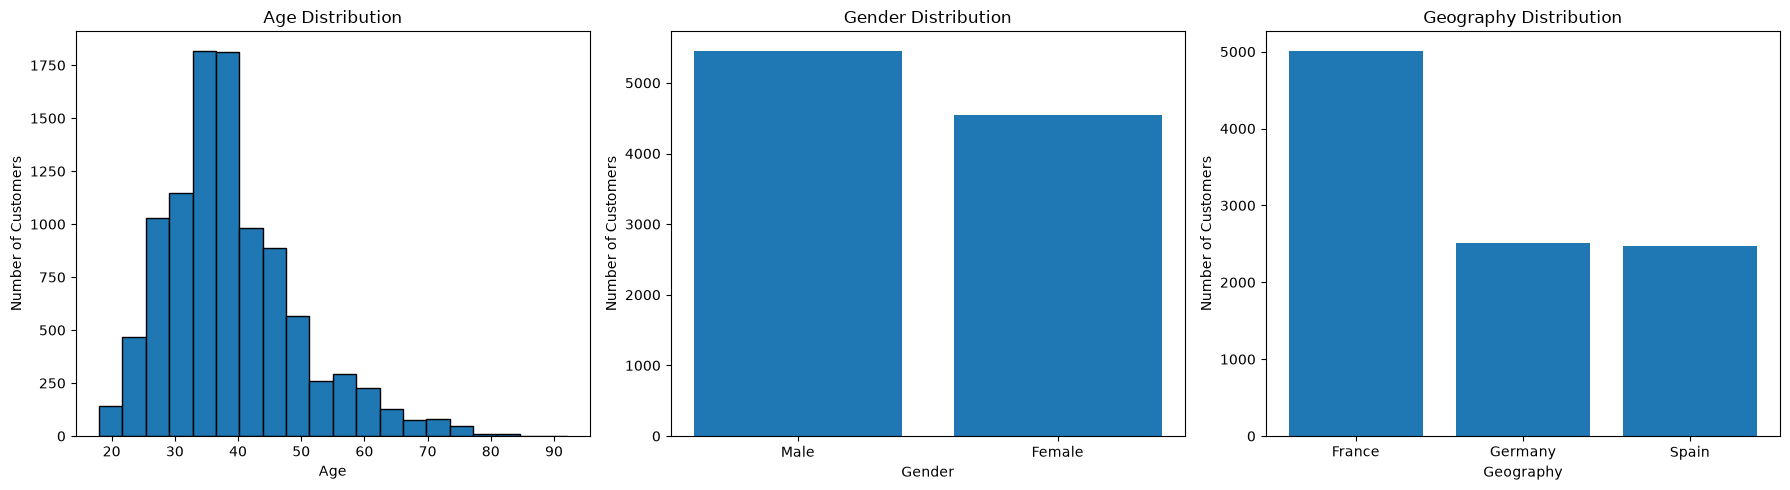

In [124]:
# ==========================================
# 3.1.2 Visual Exploration
# Demographic Profile
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
axes[0].hist(df_merged["Age"], bins=20, edgecolor="black")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Customers")

# Gender
gender_counts = df_merged["Gender"].value_counts()

axes[1].bar(gender_counts.index, gender_counts.values)
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Customers")

# Geography
geography_counts = df_merged["Geography"].value_counts()

axes[2].bar(geography_counts.index, geography_counts.values)
axes[2].set_title("Geography Distribution")
axes[2].set_xlabel("Geography")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Phần lớn customer tập trung ở độ tuổi trung niên 32 - 44 tuổi. Right-skewed

The dataset has a relatively balanced gender distribution, with males accounting for 54.57% and females 45.43% of customers

- customer nằm ở 3 khu vực
- hơn 50% Customer đến từ France; customer đến từ Germany và Spain khá tương đồng chiếm gần 50% lượng khách còn lại.

- Customers are distributed across three geographical regions: France, Germany, and Spain.
- France accounts for the largest proportion of customers, with 50.14%, while Gemany and Spain accounts for 25.09% and 24.77%, respectively.
- The customer distribution between Germany and Spain is relatively balanced.

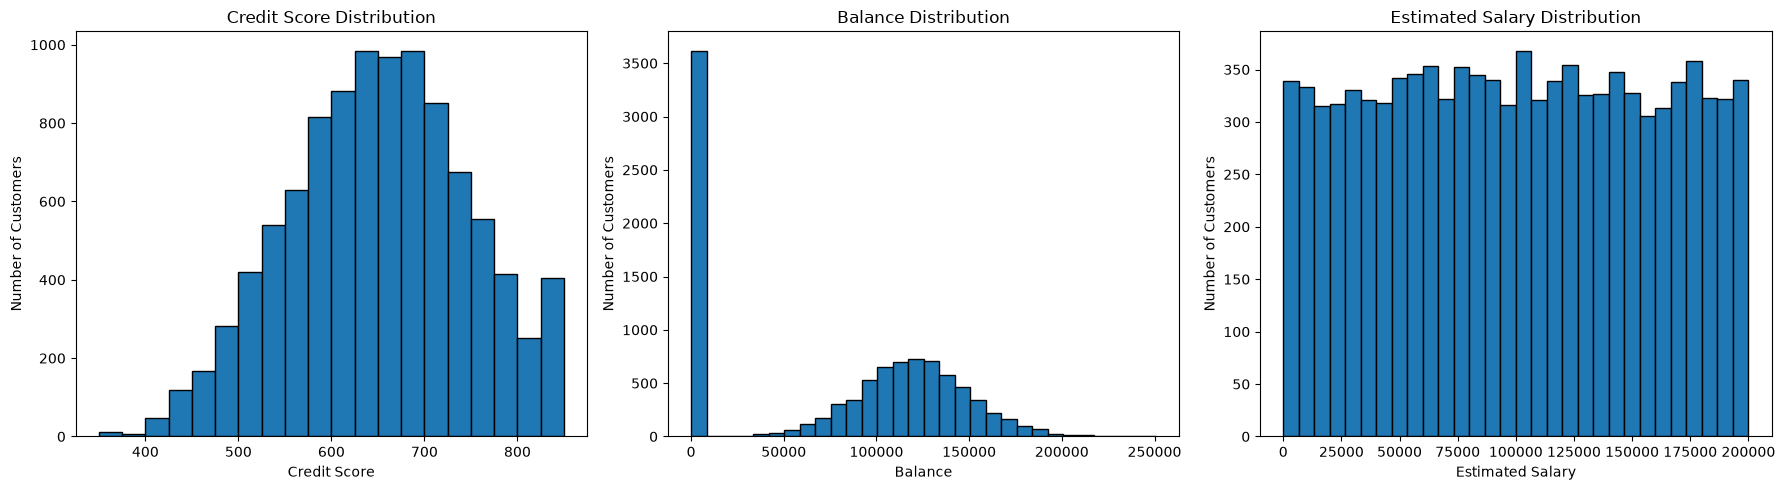

In [125]:
# ==========================================
# Financial Profile
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Credit Score
axes[0].hist(df_merged["CreditScore"], bins=20, edgecolor="black")
axes[0].set_title("Credit Score Distribution")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Number of Customers")

# Balance
axes[1].hist(df_merged["Balance"], bins=30, edgecolor="black")
axes[1].set_title("Balance Distribution")
axes[1].set_xlabel("Balance")
axes[1].set_ylabel("Number of Customers")

# Estimated Salary
axes[2].hist(df_merged["EstimatedSalary"], bins=30, edgecolor="black")
axes[2].set_title("Estimated Salary Distribution")
axes[2].set_xlabel("Estimated Salary")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

- Skewedness = -0.0716, the mean and median are very close, the CreditScore distribution is approximately summetric, with a very slight tendency toward left-skewness. 


Lượng khách hàng chủ đạo có balance = 0 chiểm số lượng nhiều nhất
- The Balance distribution is highly concentrated at zero, while customer with positive balances are mainly distributed between approximately 50,000 and 200,000.
- For customers with positive balances, the distribution should be examined further to assess its skewness and potential outliers.

- Sau khi loại bỏ Balance==0, pp mới gần cân xứng với mean~median và skewness rất nhỏ -> ko có dấu hiệu lệch.

- The overall Balance distribution is strongly affected by the large number of customers with zero balances. 
- After excluding zero-balance customers, the positive_balance distribution is approximately symmetric (skewness = 0.0256), with most balances concentrated between 100,000 and 150,000.

Xác định có outlier ko
3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
- The first quartitle is 3,768.69 - 100,181.96
- 50% of the balance_positive is 100,181.98 - 119,839.69
- The third quartitle is 139,512.29 but the max values is 250,898.090000

count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: Balance, dtype: float64
Skewness of balance_positive is 0.025624377900229683
mean 119827.49379288736
median 119839.69


np.float64(0.025624377900229683)

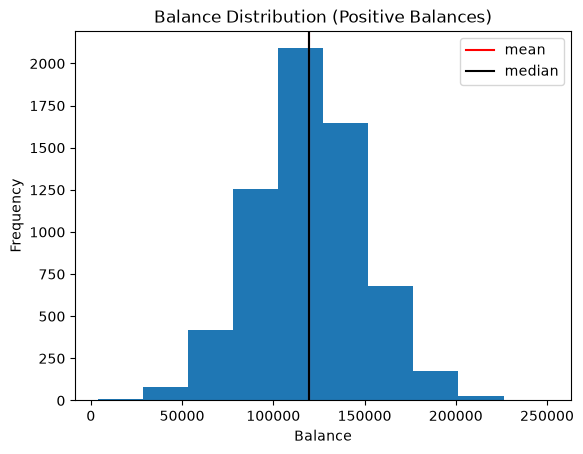

In [126]:
# df..loc[Condition, column]
balance_positive = df_merged.loc[df_merged["Balance"] > 0,
                                 "Balance"
                                 ]

print(balance_positive.describe())
print("Skewness of balance_positive is", balance_positive.skew())

plt.hist(balance_positive)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Balance Distribution (Positive Balances)")

balance_positive_mean = np.mean(balance_positive)
balance_positive_median = np.median(balance_positive)
plt.axvline(balance_positive_mean, color = "red", label = "mean")
plt.axvline(balance_positive_median, color ="black", label = "median")
plt.legend()
print("mean", balance_positive_mean)
print("median", balance_positive_median)
balance_positive.skew()

- The overall Balance distribution is strongly affected by the large number of customers with zero balances. 
- After excluding zero-balance customers, the positive_balance distribution is approximately symmetric (skewness = 0.0256), with most balances concentrated between 100,000 and 150,000.

- Sau khi loại bỏ Balance==0, pp mới gần cân xứng với mean~median và skewness rất nhỏ -> ko có dấu hiệu lệch.

#### What are their financial characteristics?
Financial and Banking Profile

Distribution of `CreditScore`

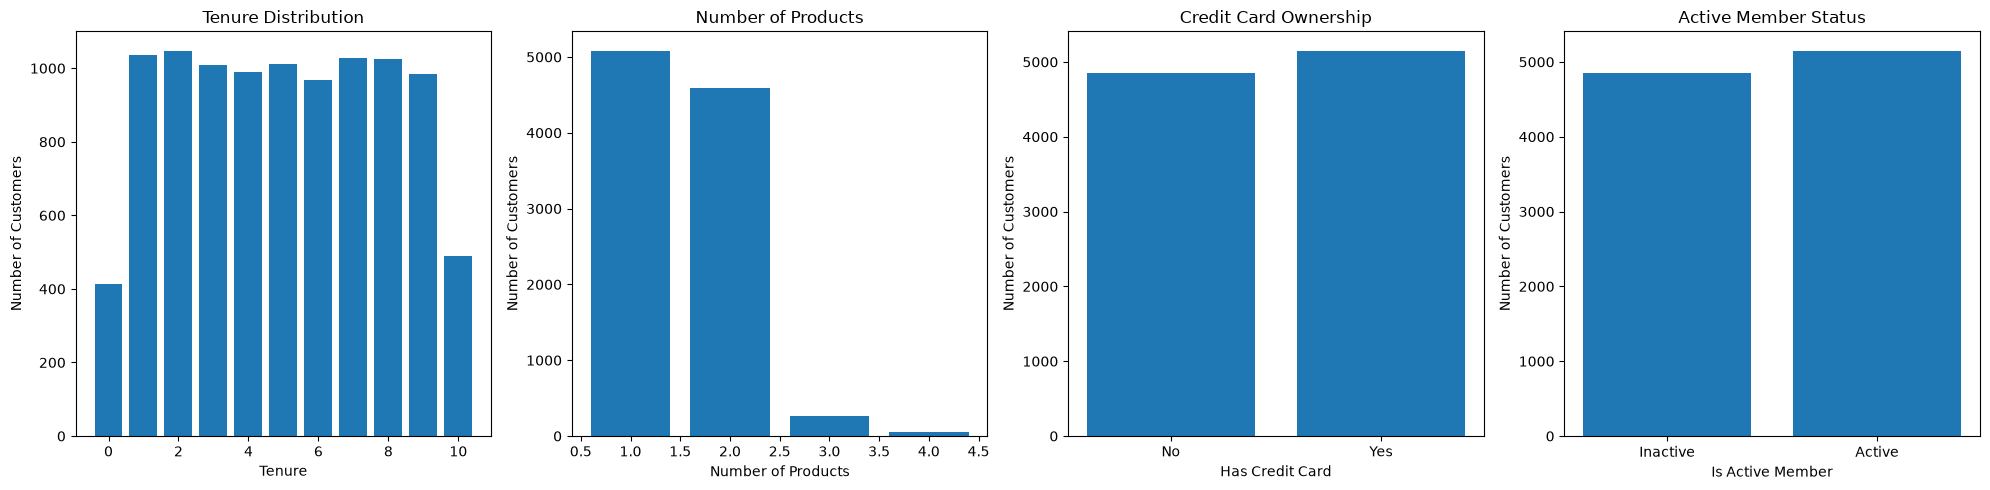

In [127]:
# ==========================================
# Banking Relationship Profile
# ==========================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Tenure
tenure_counts = df_merged["Tenure"].value_counts().sort_index()

axes[0].bar(tenure_counts.index, tenure_counts.values)
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure")
axes[0].set_ylabel("Number of Customers")

# Number of Products
products_counts = df_merged["NumOfProducts"].value_counts().sort_index()

axes[1].bar(products_counts.index, products_counts.values)
axes[1].set_title("Number of Products")
axes[1].set_xlabel("Number of Products")
axes[1].set_ylabel("Number of Customers")

# Credit Card
card_counts = df_merged["HasCrCard"].value_counts().sort_index()

axes[2].bar(
    ["No", "Yes"],
    card_counts.values
)
axes[2].set_title("Credit Card Ownership")
axes[2].set_xlabel("Has Credit Card")
axes[2].set_ylabel("Number of Customers")

# Active Member
active_counts = df_merged["IsActiveMember"].value_counts().sort_index()

axes[3].bar(
    ["Inactive", "Active"],
    active_counts.values
)
axes[3].set_title("Active Member Status")
axes[3].set_xlabel("Is Active Member")
axes[3].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

- Customers with tenure from 1 to 9 years are relative evenly distributed.
- Customers with tenure of 0 and 10 years are less represented than those with tenure from 1 to 9 years.
- Tenure = 0 represents customers who have been with the bank for less than one year or whose tenure is recorded as 0 years.

Approximately 51% of customers use one banking product, while 46% use two products, together accounting for nearly 97% of all customers.

The number of customers decrease sharply as the number of products increases, with only 326 customers using three or four products

- Customers are relatively evenly ditsributed between those with and without credit card, with 51.51% having a credit card and 48.49% not having one.

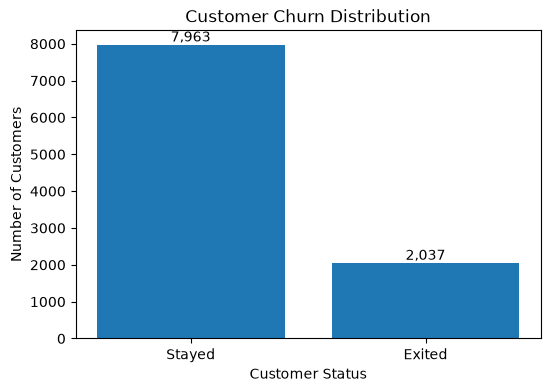

In [128]:
# ==========================================
# Target Distribution
# ==========================================

exited_counts = df_merged["Exited"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Stayed", "Exited"],
    exited_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Add exact numbers
for i, value in enumerate(exited_counts.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.show()


<div style="
    background: linear-gradient(to right, #A63D62, #E8A0B8);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #A63D62;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.25);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.4);
">
   2. What characteristics are associated with churn?
</div>

#### Do churn customers have a different age distribution compared with retained customers?

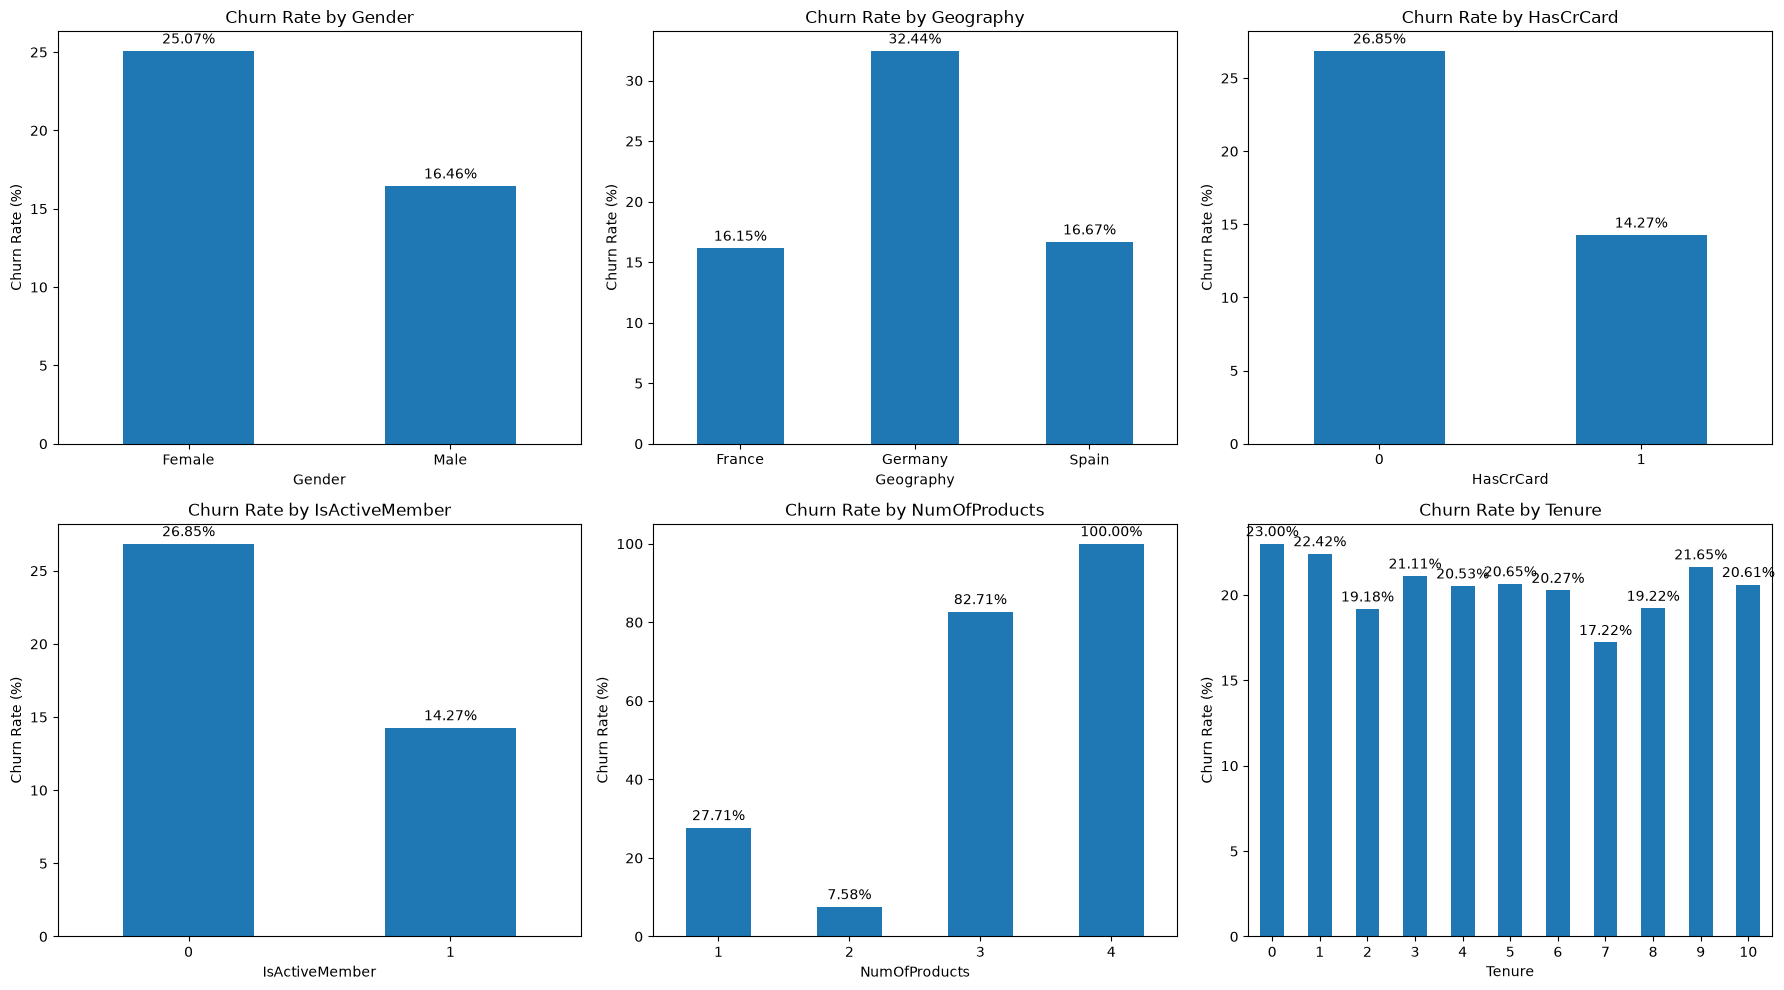

In [129]:
# ==========================================
# 3.2.2 Churn Rate by Categorical Variables
# ==========================================

categorical_vars = [
    "Gender",
    "Geography",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
    "Tenure"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, categorical_vars):
    
    churn_rate = (
        df_merged.groupby(col)["Exited"]
        .mean()
        .mul(100)
    )
    
    churn_rate.plot(
        kind="bar",
        ax=ax
    )
    # add specified values
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f%%",
            padding=3
        )
    
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

The exploratory analysis shows noticeable differences in churn rates across several customer characteristics. `Geography`, `number of products`, `gender`, `HasCrCard` and `IsActiveMember` status show particularly large differences in observed churn rates. Germany has the highest churn rate among the three countries, while inactive members and customers without a credit card also show higher churn rates. Churn varies substantially by number of products, with customers holding three or four products showing especially high churn rates. In contrast, tenure shows a relatively weaker and less consistent pattern.

Exited,0,1,All
NumOfProducts,,,
1,3675,1409,5084
2,4242,348,4590
3,46,220,266
4,0,60,60
All,7963,2037,10000


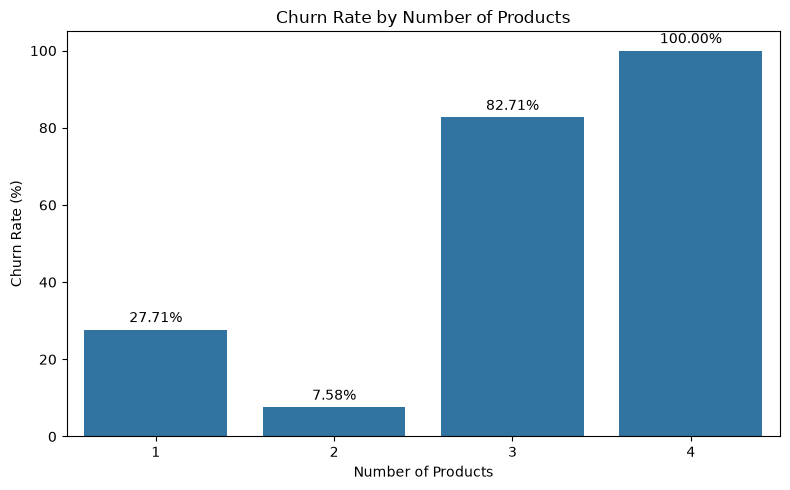

In [130]:
## churn rate by NumOffProducts
churn_rate_products = (
    df_merged.groupby("NumOfProducts")["Exited"]
      .mean()
      .mul(100)
      .reset_index(name="ChurnRate")
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_rate_products,
    x="NumOfProducts",
    y="ChurnRate"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_products["ChurnRate"].max() + 5)

plt.tight_layout()

pd.crosstab(
    df_merged["NumOfProducts"],
    df_merged["Exited"],
    margins=True
)

Customers with 3 and 4 products show exceptionally high churn rates; however, these groups contain very few customers, so the results should be interpreted with caution.

Tỷ lệ churn ở `NumOfProducts` =3, 4 cao hơn đáng kể với 1 và 2 

In [131]:
product_churn = (
    df_merged.groupby("NumOfProducts")["Exited"]
    .agg(
        Customers="count",
        Churned="sum",
        Churn_Rate="mean"
    )
)

product_churn["Churn_Rate"] = product_churn["Churn_Rate"] * 100

product_churn

,Customers,Churned,Churn_Rate
NumOfProducts,,,
1,5084,1409,27.714398
2,4590,348,7.581699
3,266,220,82.706767
4,60,60,100.000000


Nhóm 3–4 products có churn cực kỳ cao

3 products: 82.71%
4 products: 100%

Nhưng nhóm này chỉ có:

266 + 60 = 326 / 10,000 = 3.26% khách hàng

→ Vì vậy không được kết luận đơn giản rằng “càng nhiều sản phẩm càng churn”.

Thực tế nhóm 2 products lại chỉ churn 7.58%, thấp hơn rất nhiều so với nhóm 1 product (27.71%).

Nó cho thấy quan hệ không tuyến tính / không monotonic.

`Numerical variables`

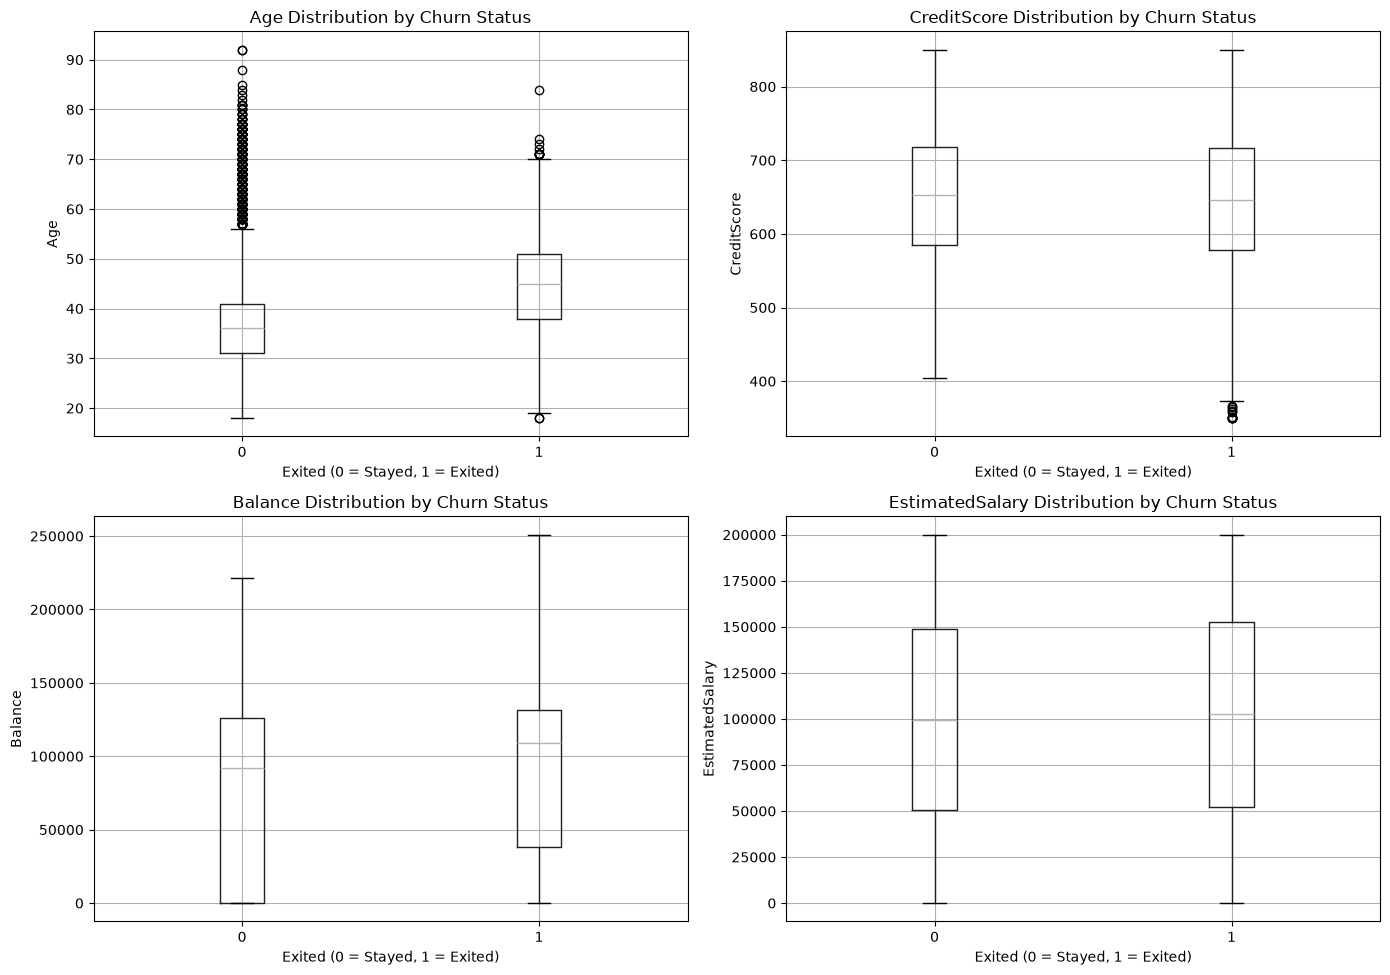

In [132]:
# ==========================================
# 3.2.3 Numerical Variables vs Churn
# ==========================================

import matplotlib.pyplot as plt

numerical_vars = [
    "Age",
    "CreditScore",
    "Balance",
    "EstimatedSalary"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, numerical_vars):
    
    df_merged.boxplot(
        column=col,
        by="Exited",
        ax=ax
    )
    
    ax.set_title(f"{col} Distribution by Churn Status")
    ax.set_xlabel("Exited (0 = Stayed, 1 = Exited)")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

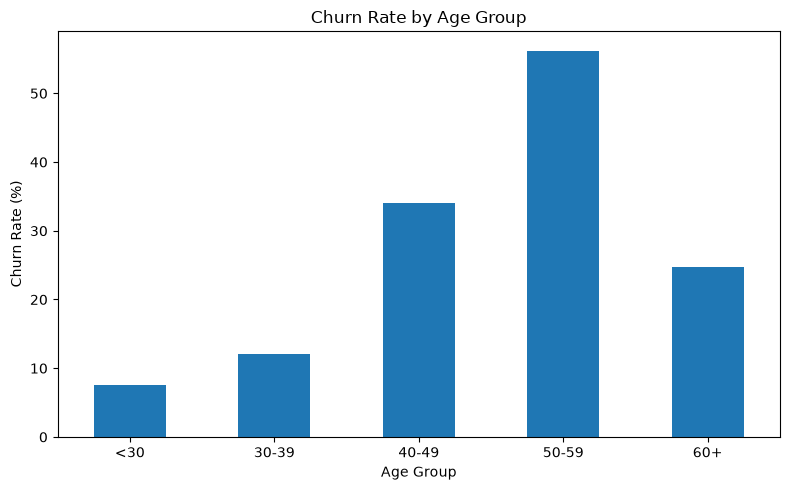

In [133]:
# ==========================================
# Churn Rate by Age Group
# ==========================================

df_merged["AgeGroup"] = pd.cut(
    df_merged["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-39", "40-49", "50-59", "60+"]
)

age_churn_rate = (
    df_merged.groupby("AgeGroup", observed=True)["Exited"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))

age_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Statistical**

✅ Are the Assumptions of T-Test and ANOVA the Same?
Yes — T-Test and ANOVA share very similar assumptions, as both are parametric tests used to compare group means. However, there are slight differences due to their intended use.

✅ Common Assumptions for Both T-Test and ANOVA

| **Assumption**                 | **T-Test**                                        | **ANOVA**                             |
| ------------------------------ | ------------------------------------------------- | ------------------------------------- |
| **1. Dependent variable**      | Continuous                                        | Continuous                            |
| **2. Grouping variable**       | Categorical with **2 groups**                     | Categorical with **3 or more groups** |
| **3. Normality**               | Data in each group should be normally distributed | Same as T-Test                        |
| **4. Homogeneity of variance** | Equal variances across groups (`equal_var=True`)  | Same as T-Test                        |
| **5. Independence**            | Observations must be independent                  | Same as T-Test                        |

🔄 Key Differences Between T-Test and ANOVA

| **Criterion**           | **T-Test**                   | **ANOVA**                                       |
| ----------------------- | ---------------------------- | ----------------------------------------------- |
| Number of groups        | Compares **2 groups**        | Compares **3 or more groups**                   |
| Post-hoc tests required | Not required                 | Required if significant (e.g., **Tukey’s HSD**) |
| Types of tests          | Independent or Paired T-Test | One-Way or Repeated Measures ANOVA              |

📌 Alternatives When Assumptions Are Violated

| **Violation**           | **T-Test Alternative**  | **ANOVA Alternative**   |
| ----------------------- | ----------------------- | ----------------------- |
| Non-normal distribution | **Mann–Whitney U Test** | **Kruskal–Wallis Test** |
| Unequal variances       | **Welch’s T-Test**      | **Welch’s ANOVA**       |

**Statistical hypothesis**

Null hypothesis — H₀

There is no association between the customer characteristic and churn.
The two categorical variables are independent.

Alternative hypothesis — H₁

There is an association between the customer characteristic and churn.
The two categorical variables are not independent.

Significance level
α=0.05

**Decision rule**

p-value < 0.05
→ Reject H₀
→ Evidence of a statistically significant association

p-value ≥ 0.05
→ Fail to reject H₀
→ Insufficient evidence of an association

The **Chi-square** test of independence is used because both the explanatory variables and the target variable (Exited) are categorical. The test evaluates whether the distribution of churn status differs across categories of each customer characteristic.

In [134]:
categorical_vars = [
    "Gender",
    "Geography",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
    "Tenure"
]

gender_table = pd.crosstab(
    df_merged["Gender"],
    df_merged["Exited"]
)

gender_table

for col in categorical_vars:
    
    print(f"\n{'='*50}")
    print(f"{col} × Exited")
    print(f"{'='*50}")
    
    table = pd.crosstab(
        df_merged[col],
        df_merged["Exited"]
    )
    
    print(table)
    




Gender × Exited
Exited     0     1
Gender            
Female  3404  1139
Male    4559   898

Geography × Exited
Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413

HasCrCard × Exited
Exited        0     1
HasCrCard            
0          3547  1302
1          4416   735

IsActiveMember × Exited
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735

NumOfProducts × Exited
Exited            0     1
NumOfProducts            
1              3675  1409
2              4242   348
3                46   220
4                 0    60

Tenure × Exited
Exited    0    1
Tenure          
0       318   95
1       803  232
2       847  201
3       796  213
4       786  203
5       803  209
6       771  196
7       851  177
8       828  197
9       771  213
10      389  101


In [135]:
from scipy.stats import chi2_contingency

categorical_vars = [
    "Gender",
    "Geography",
    "HasCrCard",
    "IsActiveMember",
    "NumOfProducts",
    "Tenure"
]

alpha = 0.05

for var in categorical_vars:
    table = pd.crosstab(df_merged[var], df_merged["Exited"])
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    print(f"\n{'='*60}")
    print(f"Variable: {var}")
    print(f"{'='*60}")
    print(f"Chi-square statistic: {chi2:.3f}")
    print(f"p-value: {p_value:.5f}")
    print(f"Degrees of freedom: {dof}")
    
    if p_value < alpha:
        print("Conclusion: Reject H0")
        print(f"There is a statistically significant association between {var} and Exited.")
    else:
        print("Conclusion: Fail to reject H0")
        print(f"There is no statistically significant association between {var} and Exited.")


Variable: Gender
Chi-square statistic: 112.919
p-value: 0.00000
Degrees of freedom: 1
Conclusion: Reject H0
There is a statistically significant association between Gender and Exited.

Variable: Geography
Chi-square statistic: 301.255
p-value: 0.00000
Degrees of freedom: 2
Conclusion: Reject H0
There is a statistically significant association between Geography and Exited.

Variable: HasCrCard
Chi-square statistic: 242.985
p-value: 0.00000
Degrees of freedom: 1
Conclusion: Reject H0
There is a statistically significant association between HasCrCard and Exited.

Variable: IsActiveMember
Chi-square statistic: 242.985
p-value: 0.00000
Degrees of freedom: 1
Conclusion: Reject H0
There is a statistically significant association between IsActiveMember and Exited.

Variable: NumOfProducts
Chi-square statistic: 1503.629
p-value: 0.00000
Degrees of freedom: 3
Conclusion: Reject H0
There is a statistically significant association between NumOfProducts and Exited.

Variable: Tenure
Chi-square sta

In [136]:
numeric_vars = [
    "CreditScore",
    "Age",
    "Balance",
    "EstimatedSalary"
]

from scipy.stats import mannwhitneyu
import pandas as pd

numeric_vars = [
    "CreditScore",
    "Age",
    "Balance",
    "EstimatedSalary"
]

alpha = 0.05

results = []

for var in numeric_vars:
    
    churned = df_merged.loc[df_merged["Exited"] == 1, var].dropna()
    retained = df_merged.loc[df_merged["Exited"] == 0, var].dropna()
    
    # Mann-Whitney U test
    statistic, p_value = mannwhitneyu(
        churned,
        retained,
        alternative="two-sided"
    )
    
    if p_value < alpha:
        conclusion = "Reject H0"
    else:
        conclusion = "Fail to reject H0"
    
    results.append({
        "Variable": var,
        "Test": "Mann-Whitney U",
        "Statistic": statistic,
        "p-value": p_value,
        "Conclusion": conclusion
    })

numeric_test_results = pd.DataFrame(results)

numeric_test_results

,Variable,Test,Statistic,p-value,Conclusion
0,CreditScore,Mann-Whitney U,7839548.0,1.986866e-02,Reject H0
1,Age,Mann-Whitney U,11874990.5,2.917835e-230,Reject H0
2,Balance,Mann-Whitney U,9371186.5,1.115840e-28,Reject H0
3,EstimatedSalary,Mann-Whitney U,8250567.0,2.277172e-01,Fail to reject H0


In [137]:
summary = []

for var in numeric_vars:
    
    retained = df_merged.loc[df_merged["Exited"] == 0, var]
    churned = df_merged.loc[df_merged["Exited"] == 1, var]
    
    summary.append({
        "Variable": var,
        "Median_Retained": retained.median(),
        "Median_Churned": churned.median(),
        "Mean_Retained": retained.mean(),
        "Mean_Churned": churned.mean()
    })

numeric_summary = pd.DataFrame(summary)

numeric_summary

,Variable,Median_Retained,Median_Churned,Mean_Retained,Mean_Churned
0,CreditScore,653.00,646.00,651.853196,645.351497
1,Age,36.00,45.00,37.408012,44.837997
2,Balance,92072.68,109349.29,72745.296779,91108.539337
3,EstimatedSalary,99654.13,102460.84,99740.929221,101465.677531



| Feature            | Type        | Statistical Test Used | Relationship with Exited | Summary                                                                  |
| ------------------ | ----------- | --------------------- | ------------------------ | ------------------------------------------------------------------------ |
| **Gender**         | Categorical | Chi-Square Test       |✅Significant              |**Female** customers a have higher churn rate (25.07) than male customers (16.46%)                                                                         |
| **Geography**      | Categorical | Chi-Square Test       | ✅ Significant            | Customers from Germany have a slightly higher churn rate than France and Spain  |
| **HasCrCard**      | Categorical | Chi-Square Test       | ✅ Significant          |Customers with Credit card (26.85%) have a slightly higher churn rate than customers without Credit card (14.27%)       |
| **IsActiveMember** | Categorical | Chi-Square Test       | ✅ Significant            |Inactive customers are more likely to churn                   |
| **NumOfProducts**  | Categorical | Chi-Square Test       | ✅ Significant            |Customers with 3 or 4 products tend to churn more              |
| **Tenure**         | Categorical | Chi-Square Test       | ❌ Not significant        |There is no evidence that Tenure is significant associated with churn  |
| **CreditScore**    | Numerical   | Mann–Whitney U Test   | ✅ Significant            |Churned customers tend to have a lower CreditScore than non-churned customers    |
| **Age**            | Numerical   | Mann–Whitney U Test   | ✅ Significant            |Churned Customers tend to be **older on median**                 |
| **Balance**        | Numerical   | Mann–Whitney U Test   | ✅ Significant            |Churned customers have a higher **median balance**              |
| **EstimatedSalary**| Numerical   | Mann–Whitney U Test   | ❌ Not significant        |There is no evidence that EstimatedSalary is significant associated with churn            |



### Multivariate Analysis

#### Why Germany have the highest churn rate?

In [138]:
# Filter churned customers only

df_churned = df_merged[
    df_merged["Exited"] == 1
].copy()



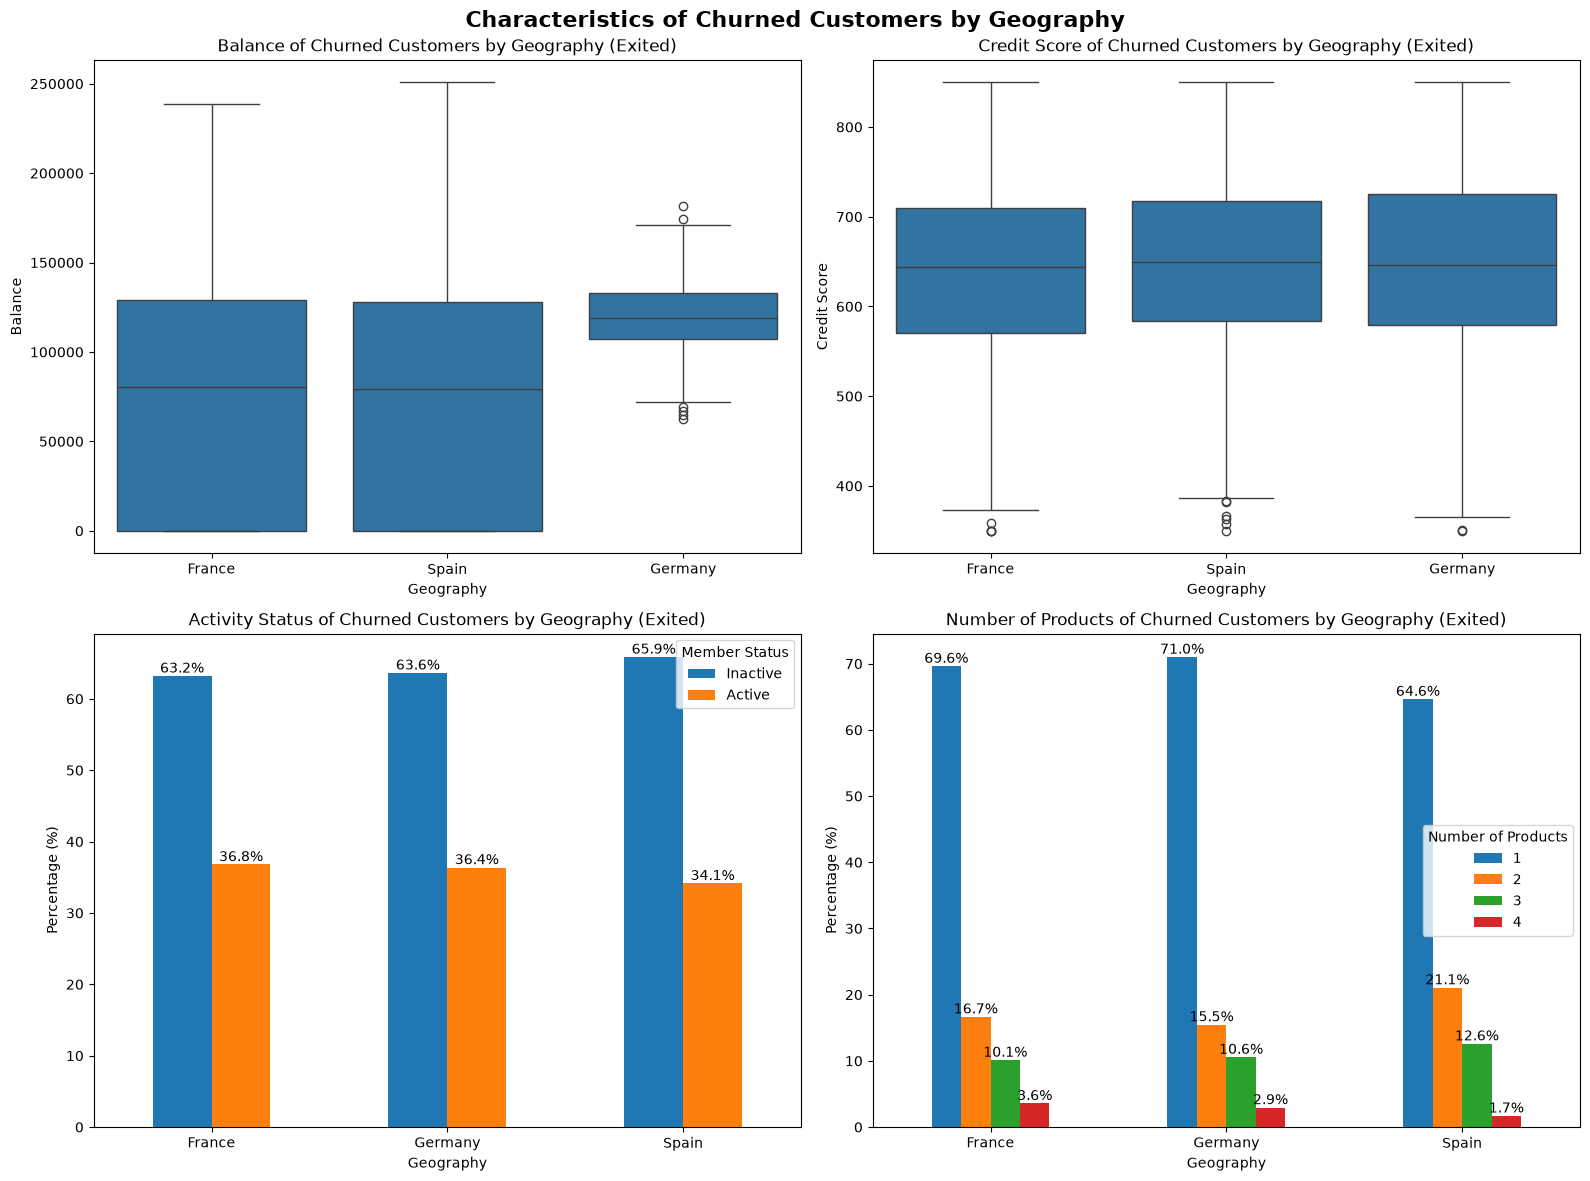

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# ==========================================
# 1. Balance by Geography
# ==========================================

sns.boxplot(
    data=df_churned,
    x="Geography",
    y="Balance",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Balance of Churned Customers by Geography (Exited)")
axes[0, 0].set_xlabel("Geography")
axes[0, 0].set_ylabel("Balance")

# ==========================================
# 2. CreditScore by Geography
# ==========================================

sns.boxplot(
    data=df_churned,
    x="Geography",
    y="CreditScore",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Credit Score of Churned Customers by Geography (Exited)")
axes[0, 1].set_xlabel("Geography")
axes[0, 1].set_ylabel("Credit Score")


# ==========================================
# 3. IsActiveMember by Geography
# ==========================================
active_geo = pd.crosstab(
    df_churned["Geography"],
    df_churned["IsActiveMember"],
    normalize="index"
) * 100

active_geo.columns = ["Inactive", "Active"]

ax = active_geo.plot(
    kind="bar",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Activity Status of Churned Customers by Geography (Exited)")
axes[1, 0].set_xlabel("Geography")
axes[1, 0].set_ylabel("Percentage (%)")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(title="Member Status")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
    
# ==========================================
# 4. NumOfProducts by Geography
# ==========================================

products_geo = pd.crosstab(
    df_churned["Geography"],
    df_churned["NumOfProducts"],
    normalize="index"
) * 100

ax = products_geo.plot(
    kind="bar",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Number of Products of Churned Customers by Geography (Exited)")
axes[1, 1].set_xlabel("Geography")
axes[1, 1].set_ylabel("Percentage (%)")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(title="Number of Products")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

# ==========================================
# Overall title
# ==========================================

plt.suptitle(
    "Characteristics of Churned Customers by Geography",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


Customers from Germany have a noticeable higher median account balance compared to those in France and Spain. This suggest that **Germany customers tend to exit despite having larger account balance**.

In contrast, `CreditScore`, `IsActiveMember`, `NumOffProducts` show relatively similar distributions across the three geographical groups, with no subtaintial differences observed among churned customers.

### Why do females have a higher churn rate compared to males?

C:\Users\Redmi\AppData\Local\Temp\ipykernel_13256\4097506461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Redmi\AppData\Local\Temp\ipykernel_13256\4097506461.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


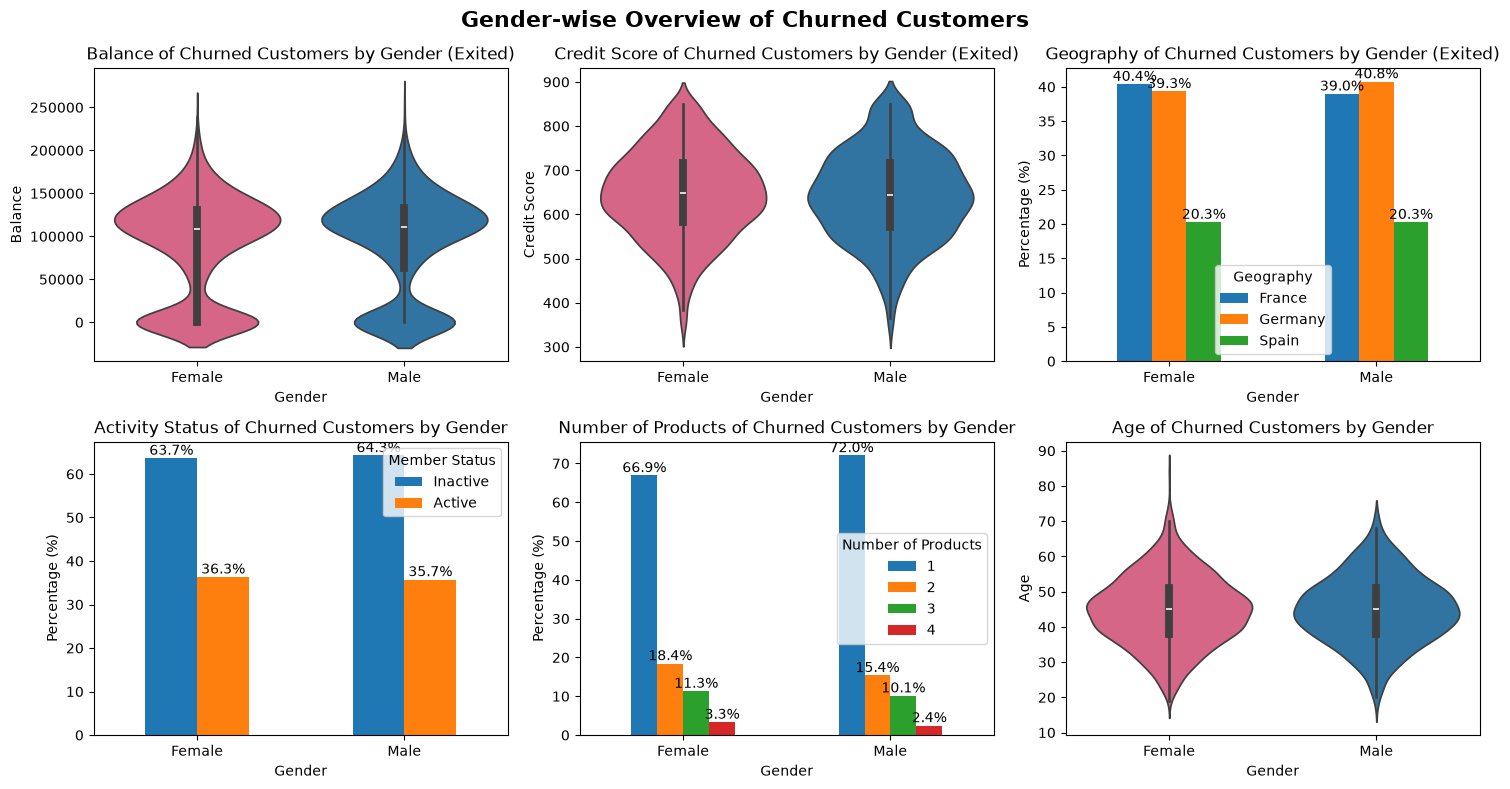

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Define palette
gender_colors = {"Male": "C0", "Female": "#E75480"}

# ==========================================
# 1. Balance by Gender (axes[0, 0])
# ==========================================
sns.violinplot(
    data=df_churned,
    x="Gender",
    y="Balance",
    palette=gender_colors,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Balance of Churned Customers by Gender (Exited)")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Balance")

# ==========================================
# 2. CreditScore by Gender (axes[0, 1])
# ==========================================
sns.violinplot(
    data=df_churned,
    x="Gender",
    y="CreditScore",
    palette=gender_colors,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Credit Score of Churned Customers by Gender (Exited)")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Credit Score")

# ==========================================
# 3. Geography by Gender (axes[0, 2])
# ==========================================
geography_gender = pd.crosstab(
    df_churned["Gender"],
    df_churned["Geography"],
    normalize="index"
) * 100

ax3 = geography_gender.plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Geography of Churned Customers by Gender (Exited)")
axes[0, 2].set_xlabel("Gender")
axes[0, 2].set_ylabel("Percentage (%)")
axes[0, 2].tick_params(axis="x", rotation=0)
axes[0, 2].legend(title="Geography")

for container in ax3.containers:
    ax3.bar_label(container, fmt="%.1f%%")

# ==========================================
# 4. IsActiveMember by Gender (axes[1, 0])
# ==========================================
active_gender = pd.crosstab(
    df_churned["Gender"],
    df_churned["IsActiveMember"],
    normalize="index"
) * 100
active_gender.columns = ["Inactive", "Active"]

ax4 = active_gender.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Activity Status of Churned Customers by Gender")
axes[1, 0].set_xlabel("Gender")
axes[1, 0].set_ylabel("Percentage (%)")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(title="Member Status")

for container in ax4.containers:
    ax4.bar_label(container, fmt="%.1f%%")

# ==========================================
# 5. NumOfProducts by Gender (axes[1, 1])
# ==========================================
products_gender = pd.crosstab(
    df_churned["Gender"],
    df_churned["NumOfProducts"],
    normalize="index"
) * 100

ax5 = products_gender.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Number of Products of Churned Customers by Gender")
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Percentage (%)")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].legend(title="Number of Products")

for container in ax5.containers:
    ax5.bar_label(container, fmt="%.1f%%")

# ==========================================
# 6. Age by Gender (axes[1, 2])
# ==========================================
sns.violinplot(
    data=df_churned,
    x="Gender",
    y="Age",
    hue="Gender",
    palette=gender_colors,
    legend=False,
    ax=axes[1, 2]
)
axes[1, 2].set_title("Age of Churned Customers by Gender")
axes[1, 2].set_xlabel("Gender")
axes[1, 2].set_ylabel("Age")

# ==========================================
# Overall Title & Rendering
# ==========================================
plt.suptitle(
    "Gender-wise Overview of Churned Customers",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Female customers have a higher churn rate than male customers**. At 25.07 compared with 16.46%, representing a noticeable difference of 8.61 percentage points.

Howerver, among churned customers, `Balance`,`CreditScore`,`IsActiveMember`, `NumOffProducts`, `Age` or `Geography`  show relatively similar distributions between females and males. Therefor, these variables do not appear to provide a clear explaination for why female customers have a higher churn rate. Furthur analysis using other customer characteristics or a multivariate model may be needed to identify the factors associated with the gender difference in churn.




### Which age group demontrates the strongest products engagement?

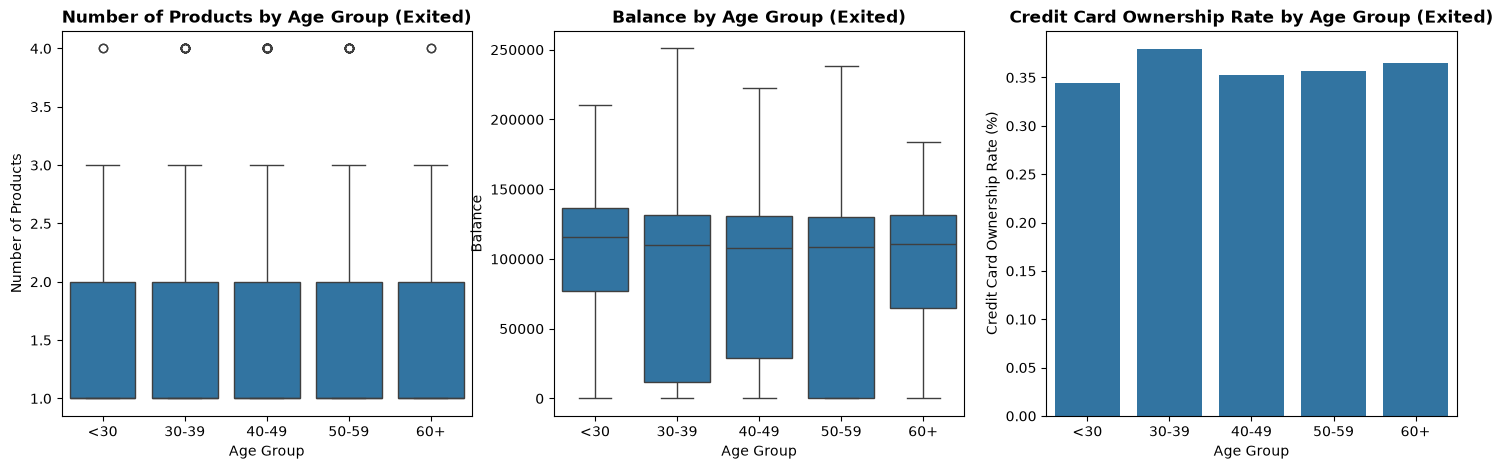

In [141]:
# NumOffProducts by Age group
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df_churned,
    x="AgeGroup",
    y="NumOfProducts",
    ax=ax[0]
)

ax[0].set_title("Number of Products by Age Group (Exited)", weight="bold")
ax[0].set_xlabel("Age Group")
ax[0].set_ylabel("Number of Products")

# Account Balance by Age Group
sns.boxplot(
    data=df_churned,
    x="AgeGroup",
    y="Balance",
    ax=ax[1]
)

ax[1].set_title("Balance by Age Group (Exited)", weight="bold")
ax[1].set_xlabel("Age Group")
ax[1].set_ylabel("Balance")

# Creditcard ownership rate by Age Group
card_rate = df_churned.groupby("AgeGroup")["HasCrCard"].apply(lambda x: x.astype(int).mean()).reset_index()

sns.barplot(
    data=card_rate,
    x="AgeGroup",
    y="HasCrCard",
    ax=ax[2]
)

plt.title("Credit Card Ownership Rate by Age Group (Exited)", weight="bold")
plt.xlabel("Age Group")
plt.ylabel("Credit Card Ownership Rate (%)")
plt.show()


No specific age group stands out in terms of product usage.

The main difference lies in the `Balance` feature. The median balance is relatively similar across Age groups. However, customers in the 30-39 `Age Group` tend to have slightly higher balances, while the 50-59 Age group has a balance close to zero.



### What are the characteristics of the group with a zero account balance?

#### Percentage of customers with zero account balance

In [142]:
zero_balance_pct = (df_churned['Balance'] == 0).mean() * 100
print(f"Percentage of customers with zero account balance: {zero_balance_pct:.2f}%")

Percentage of customers with zero account balance: 24.55%


In [143]:
q1 = df_churned[df_churned["Balance"] > 0]["Balance"].quantile(0.25)
q3 = df_churned["Balance"].quantile(0.75)


def classify_balance(balance):
    if balance == 0:
        return "Zero"
    elif balance <= q1:
        return "Low"
    elif balance <= q3:
        return "Mid"
    else:
        return "High"

df_churned["BalanceGroup"] = df_churned["Balance"].apply(classify_balance)

Text(0, 0.5, '')

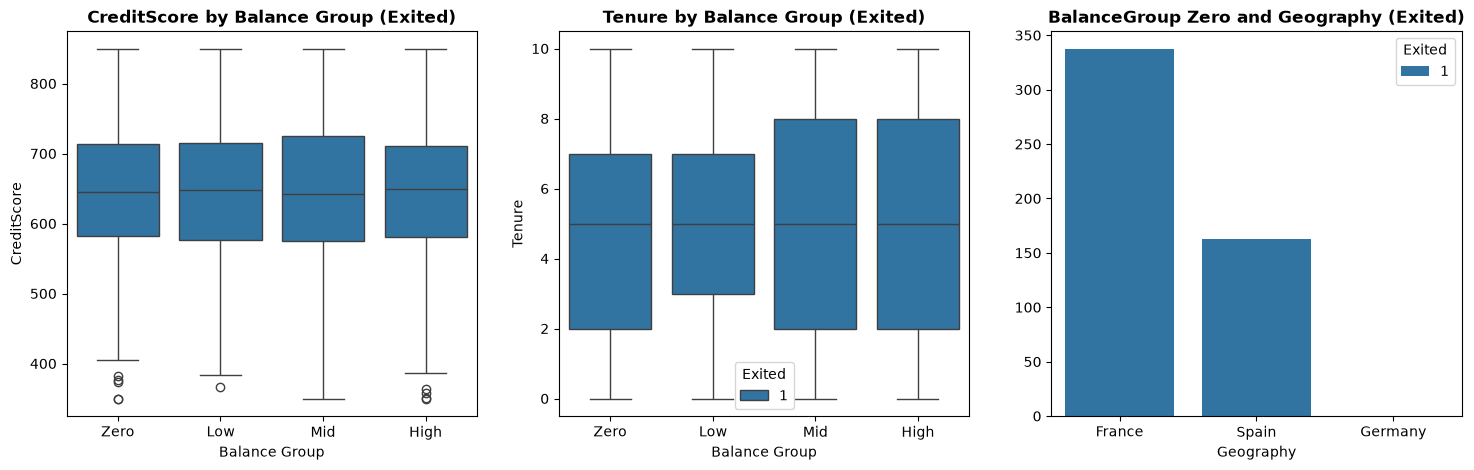

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
order = ["Zero", "Low", "Mid", "High"]

# 1. CreditScore by Balance Group
sns.boxplot(
    x="BalanceGroup",
    y="CreditScore",
    data=df_churned,
    ax=ax[0],
    order=order, 
)

ax[0].set_title("CreditScore by Balance Group (Exited)", weight="bold")
ax[0].set_xlabel("Balance Group")
ax[0].set_ylabel("CreditScore")

# 2. Tenure by Balance Group
sns.boxplot(
    x="BalanceGroup",
    y="Tenure",
    data=df_churned,
    ax=ax[1],
    hue="Exited",
    order=order,
)
ax[1].set_title("Tenure by Balance Group (Exited)", weight="bold")
ax[1].set_xlabel("Balance Group")
ax[1].set_ylabel("Tenure")

# 3. BalanceGroup and Geography
sns.countplot(x="Geography",
              data=df_churned[df_churned["BalanceGroup"] == "Zero"],
              ax=ax[2],
              hue="Exited",
              order=["France", "Spain", "Germany"],
              )
ax[2].set_title("BalanceGroup Zero and Geography (Exited)", weight="bold")
ax[2].set_ylabel("")

A zero account balance **does not indicate any notable differences** in `CreditScore`, `Tenure`.

There is no customer from Germany with zero account balance. Meanwhile, **France has a large number** of zero-balance customers and **Spain also has a considerable portion** of customers with zero balance.

### Are customers making good use of the bank's financial services?

In [145]:
# Create Credit Utilization = Balance / Estimated Salary  ---  Balance to Salary ratio
df_merged["CreditUtilization"] = df_merged["Balance"] / df_merged["EstimatedSalary"]

# Compute quantile thresholds
quantiles = df_merged["CreditUtilization"].quantile([0.33, 0.66])

# Categorize utilization levels
def categorize_utilization(x):
    if x <= quantiles[0.33]:
        return "Low"
    elif x <= quantiles[0.66]:
        return "Medium"
    else:
        return "High"

# Apply categorization
df_merged["UtilizationLevel"] = df_merged["CreditUtilization"].apply(categorize_utilization)

In [146]:
util_churn_summary = (
    df_merged
    .groupby("UtilizationLevel")["Exited"]
    .mean()
    .reset_index()
    .rename(columns={"Exited": "ChurnRate"})
)

# Convert to percentage
util_churn_summary["ChurnRate"] = (util_churn_summary["ChurnRate"] * 100).round(2)
print(util_churn_summary)

  UtilizationLevel  ChurnRate
0             High      23.94
1              Low      13.82
2           Medium      24.24


C:\Users\Redmi\AppData\Local\Temp\ipykernel_13256\2540341599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


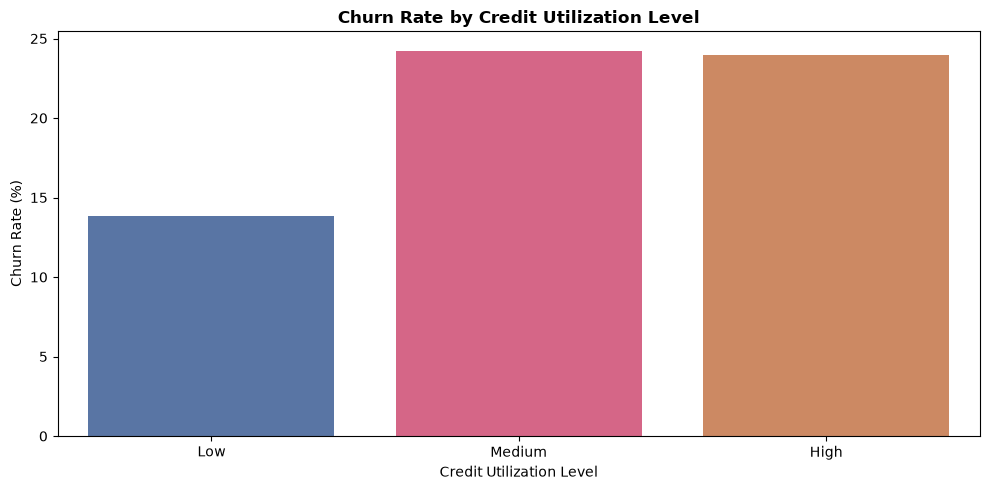

In [147]:
plt.figure(figsize=(10, 5))
custom_palette = ["#4C72B0", "#E75480", "#DD8452"]
sns.barplot(
    data=util_churn_summary,
    x="UtilizationLevel",
    y="ChurnRate",
    order=["Low", "Medium", "High"],
    palette=custom_palette,
)
plt.title("Churn Rate by Credit Utilization Level", weight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Credit Utilization Level")
plt.tight_layout()
plt.show()

**Customers with low credit utilization show significantly lower churn rates**, while both medium and high utilization groups experience similar - and much higher - churn levels.

This indicates that **customers who are heavily or moderately leveraging their credit may be at higher risk of leaving**.


<div style="
    background: linear-gradient(to right, #A63D62, #E8A0B8);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #A63D62;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.25);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.4);
">
   Define Metric
</div>

| Metric        | Definition                                                  | Meaning in Attrition Context                                          |
| ------------- | ----------------------------------------------------------- | --------------------------------------------------------------------- |
| **Recall**    | $\frac{TP}{TP + FN}$                                        | **Most important** – how many true leavers you can catch              |
| **Precision** | $\frac{TP}{TP + FP}$                                        | Among predicted leavers, how many are actually correct                |
| **Accuracy**  | $\frac{TP + TN}{Total}$                                     | Can be misleading with imbalanced data (e.g., <20% attrition)         |
| **F1-score**  | $\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$ | Balanced trade-off between Precision and Recall                       |
| **AUC-ROC**   | Area under ROC Curve                                        | Measures ability to distinguish leavers vs. stayers at all thresholds |

<div style="
    background: linear-gradient(to right, #173B63, #7FB3D5);
    color: white;
    text-align: center;
    padding: 28px;
    border-radius: 18px;
    border: 2px solid #173B63;
    box-shadow: 0 4px 10px rgba(0, 0, 0, 0.35);
    font-size: 34px;
    font-weight: bold;
    letter-spacing: 2px;
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
   EVALUATION USING CROSS-VALIDATION
</div>

### 1. Modeling Objective

The objective of this project is to build a binary classification model to predict whether a bank customer is likely to churn.

The target variable is `Exited`:
- `0`: Customer did non churn
- `1`: Customer churned

The modeling problem is therefore formulated as a binary classification task.

In [148]:
df_merged.columns.tolist()

['CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'EstimatedSalary',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'Exited',
 'AgeGroup',
 'CreditUtilization',
 'UtilizationLevel']

| Features groups | Variables |
| --- | --- |
| Original features | `CreditScore`, `Geography`, `Gender`, `Age`, `Tenure`, `EstimatedSalary`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember` |
| Derived features | `AgeGroup`, `CreditUtilization`, `UtilizationLevel`|

### 2. Fearures Selection

The baseline model uses the following customer-level features:

- CreditScore
- Geography
- Gender
- Age
- Tenure
- EstimatedSalary
- Balance
- NumOfProducts
- HasCrCard
- IsActiveMember

`CustomerId` and `Surname` are excluded because they are not appropriate predictive features for the baseline model.

The derived features `AgeGroup`, `CreditUtilization`, and `UtilizationLevel` are not included in the baseline model. They will be evaluated later as potential feature-engineering improvements.

In [149]:
#### Define x, y

features = [
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Tenure',
    'EstimatedSalary',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'
]

X = df_merged[features]
y = df_merged['Exited']

In [150]:
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (10000, 10)
y shape: (10000,)


,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember
0,619,France,Female,42,2,101348.88,0.00,1,1,1
1,608,Spain,Female,41,1,112542.58,83807.86,1,1,1
2,502,France,Female,42,8,113931.57,159660.80,3,0,0
3,699,France,Female,39,1,93826.63,0.00,2,0,0
4,850,Spain,Female,43,2,79084.1,125510.82,1,1,1


0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

### 3. Train/Test Split

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4. **Data Preprocessing**

In [152]:
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'EstimatedSalary',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'
]

categorical_features = [
    'Geography',
    'Gender'
]

```mermaid
graph TD
    Root[Data Preprocessing] --> Num[Numerical Features]
    Root --> Cat[Categorical Features]

    Num --> NumVars["Variables: CreditScore, Age, Balance"]
    Num --> NumScaler["Method: StandardScaler"]

    Cat --> CatVars["Variables: Geography, Gender"]
    Cat --> CatEncoder["Method: OneHotEncoder"]

In [153]:
## ColumnTransformer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features)
    ]
)


#### 5. **Logistic Regression Pipeline**

In [154]:
## Logistic Regression Pipline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

## Train Baseline Model

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'NumOfProducts','HasCrCard', 'IsActiveMember']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

### 6. **Model Evaluation**

In [155]:
### Predict on Test set
y_pred = logistic_model.predict(X_test)

print(y_pred[:20])

#0 → model predicts customer will NOT churn
#1 → model predicts customer WILL churn


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


#### Confusion Matrix

In [156]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1541   52]
 [ 330   77]]


In [157]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.809
Precision: 0.5968992248062015
Recall   : 0.1891891891891892
F1-score : 0.2873134328358209


**Baseline Model Evaluation**

At the default threshold of 0.5, the Logistic Regression model achieved an accuracy of 80.9%. However, the Recall was only 18.92%, meaning that the model correctly identified 77 out of 407 customers who actually churned, whill missing 330 churned customers.

The Precision was 59.69%, indicating that among customers predicted to churn, 59.69% actually churned. The F1-score was 28.73%, reflecting the trade-off between the relatively higher precision and low recall.

These results show that although the model achieves relatively high overall accuracy, it has limited ability to identify churned customers at the default threshold of 0.5.

Therefore, further evaluation is needed to determine whether this performance is stable across different subsets of the training data.

### **7. Cross-Validation**

In [158]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'recall': 'recall'
    }
)

print("Accuracy by fold:", cv_results['test_accuracy'])
print("\nRecall by fold:", cv_results['test_recall'])


print("\nMean Accuracy:", cv_results['test_accuracy'].mean())
print("\nMean Recall:", cv_results['test_recall'].mean())

Accuracy by fold: [0.81     0.8175   0.8175   0.7975   0.813125]

Recall by fold: [0.20552147 0.22699387 0.25766871 0.17484663 0.21165644]

Mean Accuracy: 0.811125

Mean Recall: 0.21533742331288344


#### Cross-Validation

Using 5-fold stratified cross-validation, the Logistic Regression model achieve a mean accuracy of 81.11% and mean recall of 21.53%.

Accuracy remained relatively stable across the five folds, ranging from 79.75% to 81.75%. Recall showed greater variation, ranging from 17.48% to 25.77%.

The cross-validation results are broadly consistent with the test-set performance at the default threshold of 0.5, where accuracy was 80.90% and recall was 18.92%.

This suggests that the model's performance is reasonably consistent across different subsets of the training data. However, the low recall indicates that the model still has limited ability to identify customers who churn at the default classification threshold.

### **8. ROC Curve & ROC-AUC**

[0.12028304 0.26926153 0.10735064 0.14098944 0.0971542  0.13976353
 0.08813128 0.36052302 0.3448771  0.218112  ]
ROC-AUC: 0.7750431479245038


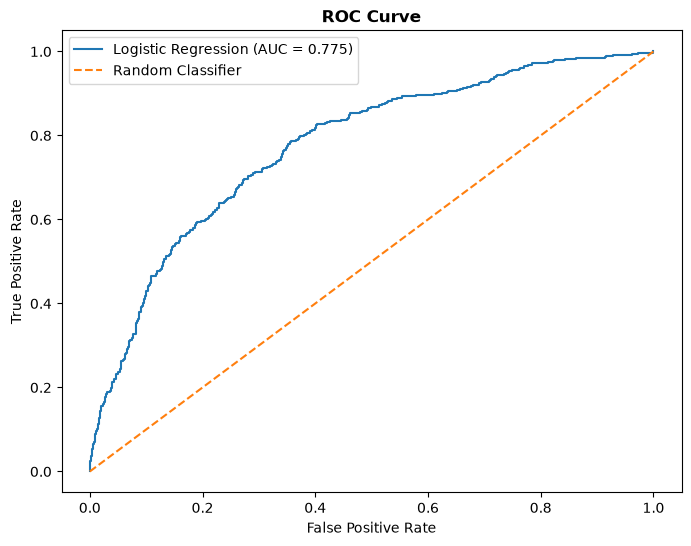

In [159]:
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print(y_proba[:10])


from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)

## Plot ROC - AUC

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", weight="bold")
plt.legend()
plt.show()

### **ROC Curve & ROC-AUC**

The Logistic Regression Model achieved a ROC-AUC of 0.775, indicating that the model has a meaningful ability to distinguish between churned and non-churned customers based on their predicted probabilities.

The ROC curve also shows the trade-off between True Positive Rate (Recall) and False Positive Rate as the classification threshold changes.

Although the recall at the default threshold of 0.5 was only 18.92%, the ROC curve suggests that higher recall can be achieved by lowering the classification threshold, at the cost of a higher false positive rate.

Therefore, the next step is to analyze different classification thresholds and evaluate the trade-of between identifying more churned customers and generating more false positives.

#### **Classification Threshold**

Precision: (2001,)
Recall: (2001,)
Thresholds: (2000,)


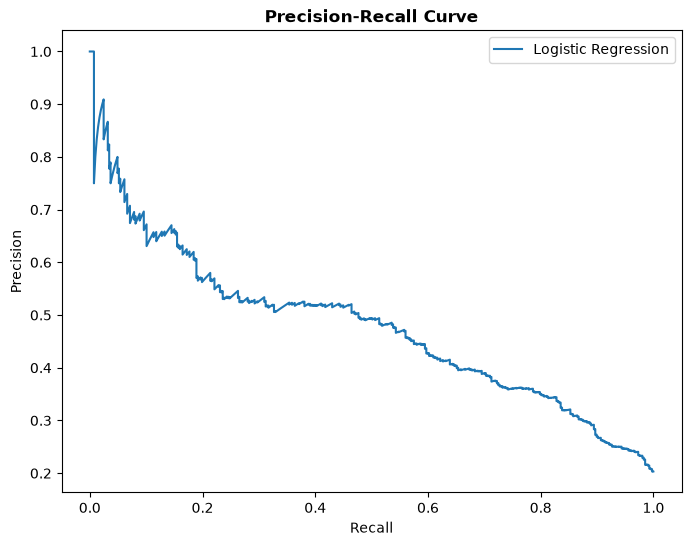

In [160]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_proba
)

print("Precision:", precision.shape)
print("Recall:", recall.shape)
print("Thresholds:", thresholds_pr.shape)


## Plot PR Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve", weight="bold")
plt.legend()
plt.show()

#### **Precision-Recall Curve Interpretation**

The Preciion-Recall curve shows the trade-off between Precision and Recall as the classification threshold changes.

- **X-axis:** Recall
- **Y-axis:** Precision

As Recall increases, Precision generally decreases. This mean that identifying more churned customers with more false positive predictions.

At the end of the curve, Precision approaches approximately 20%, which is close to the churn rate in the test set 20.35%.

In [161]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_proba)

print("PR-AUC:", pr_auc)

PR-AUC: 0.4790847525397894


The Logistic Regression model achieved a PR-AUC (Average Precision) of 0.4791.

The Precision-Recall curve evaluates the trade-off between Precision and Recall across different classification thresholds.

Since the churn rate in the test set is approximately 20.35%, the PR_AUC should be interpreted in the context of this positive-class prevalance rather than using a fixed benchmark such as 0.5.

The PR curve shows that increasing Recall generally leads to lower Precision. Therefore, the classification threshold should be selected based on the business trade-off between identifying more churned customers and generating more false positive predictions.

In [162]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    fpr = fp / (fp + tn)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr
    })
    
    
import pandas as pd

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1,FPR
0,0.1,0.266811,0.906634,0.412291,0.636535
1,0.2,0.375162,0.712531,0.491525,0.303202
2,0.3,0.482679,0.513514,0.497619,0.140615
3,0.4,0.527197,0.309582,0.390093,0.070935
4,0.5,0.596899,0.189189,0.287313,0.032643
5,0.6,0.650794,0.100737,0.174468,0.013810
6,0.7,0.761905,0.039312,0.074766,0.003139
7,0.8,0.800000,0.009828,0.019417,0.000628
8,0.9,0.000000,0.000000,0.000000,0.000000


### **Threshold Analysis**

Changing the classification threshold affects the trade-off between Precision, Recall, and False Positive Rate (FPR).

As the threshold decreases:

- Recall increases because the model becomes more likely to classify customers as churned.
- FPR increases because more non-churned customers are classified as churned.
- Precision generally decreases because more false positive predictions are generated.

For example, at a threshold of 0.5, the model achieved a Recall of 18.92% and an FPR of 3.26%. When the threshold was reduced to 0.3, Recall increased to 51.35%, while FPR increased to 14.06%.

Among the tested thresholds, 0.3 produced the highest F1-score of 49.76%. However, the final threshold should not be selected based on F1-score alone. The appropriate threshold depends on the business trade-off between identifying more churned customers and contacting customers who would not have churned.

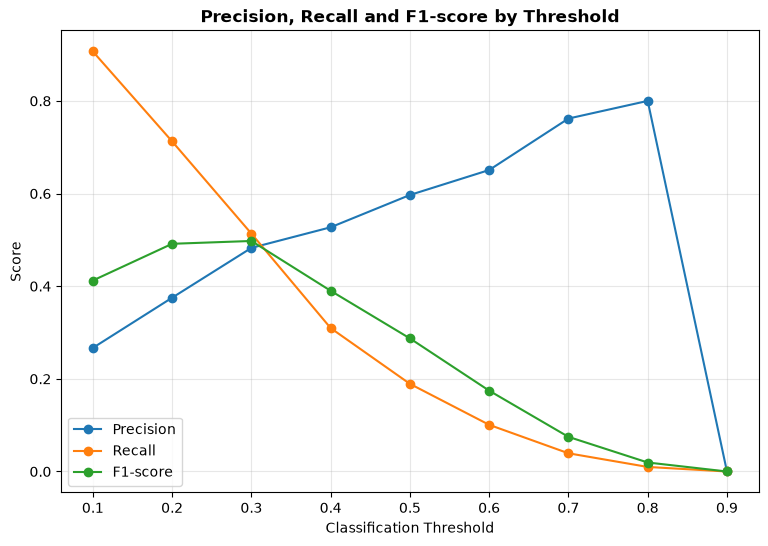

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-score by Threshold", weight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Threshold Trade-off Visualization

The plot illustrates how Precision, Recall, and F1-score change as the classification threshold varies.

Precision generally increases as the threshold increases, while Recall decreases. F1-score reflects the balance between Precision and Recall and reaches its highest value among the tested thresholds at 0.3.

This visualization helps identify potential threshold candidates and understand the trade-off between detecting more churned customers and generating more false positive predictions.

In [164]:
import pandas as pd

feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
8,cat__Geography_Germany,0.818402
1,num__Age,0.739612
4,num__Balance,0.162309
3,num__EstimatedSalary,0.047811
9,cat__Geography_Spain,0.043536
2,num__Tenure,-0.021200
5,num__NumOfProducts,-0.070532
0,num__CreditScore,-0.085571
6,num__HasCrCard,-0.257468
7,num__IsActiveMember,-0.257468


### Duplicate Information

`HasCrCard` and `IsActiveMember` were found to contain identical
values in the original dataset. Since both variables provide the same
information, `HasCrCard` was excluded from the baseline model to avoid
redundant features.

In [165]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'EstimatedSalary',
    'Balance',
    'NumOfProducts',
    'IsActiveMember'
]

categorical_features = [
    'Geography',
    'Gender'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'NumOfProducts','HasCrCard', 'IsActiveMember']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [166]:
y_pred = logistic_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

Accuracy : 0.809
Precision: 0.5968992248062015
Recall   : 0.1891891891891892
F1-score : 0.2873134328358209
[[1541   52]
 [ 330   77]]


In [167]:
import numpy as np
import pandas as pd

feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(
    "Coefficient",
    ascending=False
)

coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])

coef_df

,Feature,Coefficient,Odds_Ratio
7,cat__Geography_Germany,0.819306,2.268926
1,num__Age,0.738841,2.093507
4,num__Balance,0.162467,1.176409
3,num__EstimatedSalary,0.047886,1.049051
8,cat__Geography_Spain,0.045074,1.046105
2,num__Tenure,-0.021099,0.979122
5,num__NumOfProducts,-0.070938,0.931520
0,num__CreditScore,-0.085636,0.917929
6,num__IsActiveMember,-0.515384,0.597271
9,cat__Gender_Male,-0.522513,0.593028


### Logistic Regression Coefficients and Odds Ratios

The Logistic Regression coefficients were converted into Odds Ratios using:

\[
OR = e^{\beta}
\]

where \(\beta\) is the model coefficient.

- **Coefficient > 0 / OR > 1:** associated with higher odds of churn.
- **Coefficient < 0 / OR < 1:** associated with lower odds of churn.
- For numerical features, the variables were standardized using `StandardScaler`. Therefore, the Odds Ratio represents the change in churn odds associated with a **one-standard-deviation increase** in the feature, while holding other variables constant.
- For categorical features, the Odds Ratio compares the category with its reference category, while holding other variables constant.

The model produced the following results:

| Feature | Coefficient | Odds Ratio |
|---|---:|---:|
| Geography_Germany | 0.8193 | 2.2689 |
| Age | 0.7388 | 2.0935 |
| Balance | 0.1625 | 1.1764 |
| EstimatedSalary | 0.0479 | 1.0491 |
| Geography_Spain | 0.0451 | 1.0461 |
| Tenure | -0.0211 | 0.9791 |
| NumOfProducts | -0.0709 | 0.9315 |
| CreditScore | -0.0856 | 0.9179 |
| IsActiveMember | -0.5154 | 0.5973 |
| Gender_Male | -0.5225 | 0.5930 |

For categorical variables, `France` is the reference category for `Geography`, while `Female` is the reference category for `Gender`.

**The variables `Tenure`, `EstimatedSalary`, `NumOfProducts`, `CreditScore`
have a weak contribution to predicting `Exited`. Therefore, we can exclude them from the model.**

In [174]:
reduced_features = [
    'CreditScore',
    'Geography',
    'Gender',
    'Age',
    'Balance',
    'IsActiveMember'
]

X_reduced = df_merged[reduced_features]

print("Reduced features:", reduced_features)
print("X_reduced shape:", X_reduced.shape)

Reduced features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Balance', 'IsActiveMember']
X_reduced shape: (10000, 6)


In [178]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define feature types
numeric_features_reduced = [
    'CreditScore',
    'Age',
    'Balance',
    'IsActiveMember'
]

categorical_features_reduced = [
    'Geography',
    'Gender'
]

# Preprocessing
preprocessor_reduced = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features_reduced
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features_reduced
        )
    ]
)

# Reduced Logistic Regression model
reduced_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_reduced),
        (
            'model',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# Train the Reduced Model
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_reduced:", X_train_reduced.shape)
print("X_test_reduced:", X_test_reduced.shape)
print("y_train_reduced:", y_train_reduced.shape)
print("y_test_reduced:", y_test_reduced.shape)

# Fit the Reduced Model
reduced_model.fit(
    X_train_reduced,
    y_train_reduced
)


X_train_reduced: (8000, 6)
X_test_reduced: (2000, 6)
y_train_reduced: (8000,)
y_test_reduced: (2000,)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['CreditScore','Geography','Gender','Age','Balance','IsActiveMember']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

In [179]:
y_pred_reduced = reduced_model.predict(X_test_reduced)

print("Reduced Model Accuracy:", accuracy_score(y_test_reduced, y_pred_reduced))
print("Reduced Model Precision:", precision_score(y_test_reduced, y_pred_reduced))
print("Reduced Model Recall:", recall_score(y_test_reduced, y_pred_reduced))
print("Reduced Model F1:", f1_score(y_test_reduced, y_pred_reduced))

Reduced Model Accuracy: 0.8095
Reduced Model Precision: 0.6031746031746031
Reduced Model Recall: 0.18673218673218672
Reduced Model F1: 0.2851782363977486


### Full Model vs Reduced Model — Test Set

The performance of the Full Model and Reduced Model on the test set is compared below:

| Metric | Full Model (9 features) | Reduced Model (6 features) |
|---|---:|---:|
| Accuracy | 80.90% | 80.95% |
| Precision | 59.69% | 60.32% |
| Recall | 18.92% | 18.67% |
| F1-score | 28.73% | 28.52% |

The two models show very similar performance on the test set.

- Accuracy increased slightly from **80.90% to 80.95%**.
- Precision increased from **59.69% to 60.32%**.
- Recall decreased slightly from **18.92% to 18.67%**.
- F1-score decreased slightly from **28.73% to 28.52%**.

These differences are small, suggesting that removing `Tenure`, `EstimatedSalary`, and `NumOfProducts` did not materially change the model's test-set performance.

However, test-set performance alone is not sufficient to determine whether the reduced model is preferable. Cross-validation will be used to evaluate whether the model's performance remains stable across different training subsets.

In [180]:
cv_results_reduced = cross_validate(
    reduced_model,
    X_train_reduced,
    y_train_reduced,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'recall': 'recall'
    }
)

print("Reduced Model CV Accuracy:")
print(cv_results_reduced['test_accuracy'])

print("\nReduced Model CV Recall:")
print(cv_results_reduced['test_recall'])

print("\nMean CV Accuracy:",
      cv_results_reduced['test_accuracy'].mean())

print("Mean CV Recall:",
      cv_results_reduced['test_recall'].mean())

Reduced Model CV Accuracy:
[0.8075   0.818125 0.818125 0.801875 0.810625]

Reduced Model CV Recall:
[0.19631902 0.22392638 0.2607362  0.18404908 0.21165644]

Mean CV Accuracy: 0.8112499999999999
Mean CV Recall: 0.21533742331288347


### Full Model vs Reduced Model

The Full Model and Reduced Model were compared using both test-set
performance and 5-fold stratified cross-validation.

The Reduced Model excludes `Tenure`, `EstimatedSalary`, and
`NumOfProducts`.

| Metric | Full Model | Reduced Model |
|---|---:|---:|
| Test Accuracy | 80.90% | 80.95% |
| Test Precision | 59.69% | 60.32% |
| Test Recall | 18.92% | 18.67% |
| Test F1-score | 28.73% | 28.52% |
| Mean CV Accuracy | 81.11% | 81.12% |
| Mean CV Recall | 21.53% | 21.53% |

The two models achieved very similar performance on both the test set
and cross-validation. Therefore, the three removed features did not
provide a meaningful performance improvement for the Logistic Regression
model.

The Reduced Model will be used as the candidate final model because it
achieves comparable predictive performance with fewer features, making
the model simpler to interpret.

### **Compare ROC-AUC and PR-AUC**

#### **Get churn probabilities**

In [181]:
y_proba_reduced = reduced_model.predict_proba(
    X_test_reduced
)[:, 1]

print(y_proba_reduced[:10])

[0.1264157  0.28858756 0.10959726 0.15894249 0.0861985  0.11841096
 0.09891798 0.33989342 0.32980372 0.22333345]


In [182]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

roc_auc_reduced = roc_auc_score(
    y_test_reduced,
    y_proba_reduced
)

pr_auc_reduced = average_precision_score(
    y_test_reduced,
    y_proba_reduced
)

print("Reduced Model ROC-AUC:", roc_auc_reduced)
print("Reduced Model PR-AUC:", pr_auc_reduced)

Reduced Model ROC-AUC: 0.7761605981944963
Reduced Model PR-AUC: 0.4790253750757344


### Full Model vs Reduced Model — Overall Comparison

The Full Model and Reduced Model were compared using test-set metrics,
5-fold stratified cross-validation, ROC-AUC, and PR-AUC.

| Metric | Full Model | Reduced Model |
|---|---:|---:|
| Test Accuracy | 80.90% | 80.95% |
| Test Precision | 59.69% | 60.32% |
| Test Recall | 18.92% | 18.67% |
| Test F1-score | 28.73% | 28.52% |
| Mean CV Accuracy | 81.11% | 81.12% |
| Mean CV Recall | 21.53% | 21.53% |
| ROC-AUC | 0.7750 | 0.7762 |
| PR-AUC | 0.4791 | 0.4790 |

**The two models achieved very similar performance across all evaluated
metrics. The Reduced Model uses six features instead of nine while
maintaining comparable predictive performance.**

**Therefore, the Reduced Model is selected as the candidate final model
for the next stage of the analysis.**

**The threshold analysis was conducted on the original Logistic Regression
model. Since the Reduced Model achieved nearly identical ROC-AUC, PR-AUC,
and cross-validation performance, the same threshold trade-off is used
as a reference when selecting the final operating threshold.**

## Final Model Selection

### Full Model vs Reduced Model

The Full Model and Reduced Model achieved very similar performance
across the test set and cross-validation.

The Reduced Model uses fewer features while maintaining comparable
predictive performance. Therefore, the Reduced Model is selected as
the candidate final Logistic Regression model.

The selected features are:

- CreditScore
- Geography
- Gender
- Age
- Balance
- IsActiveMember

### Business objective
Recall is prioritized because the bank wants to identify as many customers at risk of churn as possible. A higher Recall reduces the number of churned customers that the model fails to identify (False Negatives), even though this may result in more False Positives.

## Final Threshold Selection

### Business Objective

For this churn prediction problem, Recall is prioritized because the bank
aims to identify as many customers at risk of churn as possible.

A False Negative means that a customer who actually churns is not identified
by the model. Therefore, missing potential churners may reduce the
opportunity for the bank to take retention actions.

A lower classification threshold can increase Recall, but it also increases
the number of False Positives.

### Threshold Comparison

| Threshold | Precision | Recall | F1-score | FPR |
|---:|---:|---:|---:|---:|
| 0.3 | 48.27% | 51.35% | 49.76% | 14.06% |
| 0.4 | 52.72% | 30.96% | 39.01% | 7.09% |
| 0.5 | 59.69% | 18.92% | 28.73% | 3.26% |

As the threshold decreases from 0.5 to 0.3, Recall increases substantially
from 18.92% to 51.35%. This means the model can identify a larger proportion
of customers who actually churn, although the False Positive Rate also
increases from 3.26% to 14.06%.

Since the business objective prioritizes identifying potential churners,
a threshold of **0.3** is selected as the operating threshold for this
project.

The higher False Positive Rate is accepted as a trade-off for achieving
higher Recall.